## Sobreajuste de una MLP con CIFAR10

En este ejercicio trabajarás con una versión modificada del dataset CIFAR-10 que contiene una anomalía oculta. Tu objetivo que anomalía presenta el dataset a partir de un análisis de la red (su entrenamiento, sus pesos, su comportamiento, etc.).

### Contexto

Se te proporciona un pipeline de entrenamiento con un MLP sencillo sobre CIFAR-10. Al entrenar el modelo, las métricas de validación presentan un comportamiento anómalo que no responde a las causas habituales de sobreajuste.
Tu misión es actuar como un detective e investigar qué está ocurriendo, formular hipótesis y verificarlas empíricamente.

### Tareas


1. **Inspección visual del dataset**- Utiliza la función plot_samples para visualizar muestras del dataset. Establece una hipótesis.

2. **Investiga la hipótesis**. A continuación se listan elementos que puedes analizar. No todos serán útiles, y no hay un orden impuesto. Parte de la tarea es decidir qué investigar y en qué orden:

    1. Pesos del modelo — magnitud, distribución, estructura espacial
    2. Gradientes durante el entrenamiento
    3. Probabilidades de salida
    4. Activaciones intermedias
    5. Estadísticas por píxel (media, varianza, distribución por clase)
    6. Comportamiento por clase 


### Entregable

Un informe breve que recoja:

    - Las hipótesis que planteaste y por qué
    - Qué análisis realizaste para verificarlas o descartarlas
    - La causa del comportamiento anómalo si la encontraste

No se evaluará únicamente la respuesta correcta, sino el razonamiento y el proceso de investigación.


### Importación de librerías

* Hipotesis 0: Se trata de una modificacion visual en el conjunto de imagenes, alguna marca poco visible, que relaciona cada imagen con su clase. Para analizarlo voy a usar tecnicas de explicabilidad (si una no vale, probar con 2 por si esta tambien aplicando ataque adversario para una tecnica)

In [60]:
import os
try:
    from google.colab import drive
    COLAB = True
    print("Estoy en Google CoLab")
    !pip install livelossplot
except:
    os.environ["CUDA_VISIBLE_DEVICES"]="1" 
    print("No estoy en Google CoLab")
    COLAB = False
import tensorflow as tf
import pathlib
import os
import pickle as pk
import numpy as np
from matplotlib import pyplot as plt
from livelossplot import PlotLossesKerasTF


No estoy en Google CoLab


### Descarga y carga de los datos (ya normalizados)

In [61]:
URL_DATASET = "https://hdvirtual.us.es/discovirt/public.php/dav/files/3myWC5PCZPeZpek"

data_path = tf.keras.utils.get_file(
    "mnist.pk", URL_DATASET,
    extract=False,
    archive_format='pk'
)

DATA_FILE = os.path.join(pathlib.Path(data_path).parent, "mnist.pk")

(X_train, y_train), (X_test, y_test) = pk.load(open(DATA_FILE, 'rb'))

### Visualización de las muestras de entrenamiento y test

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.003921569..1.0284314].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.011764706..1.0852941].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.07450981..1.1019608].


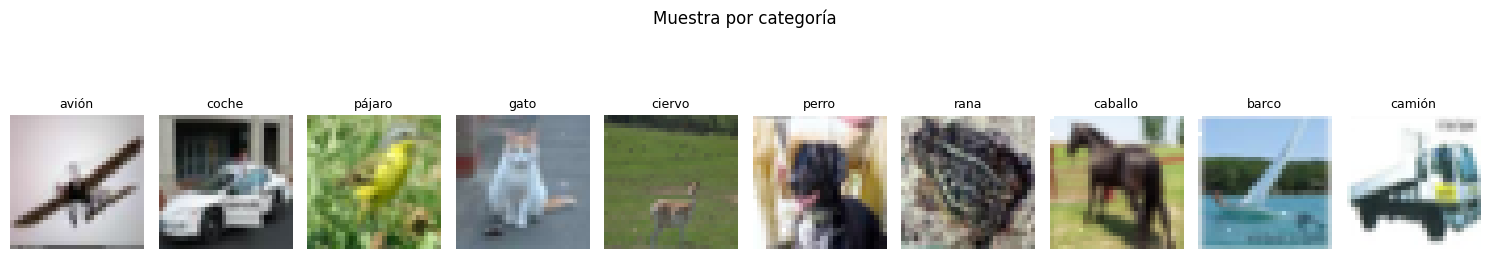

In [62]:
def plot_samples(X, y, class_names=None, figsize=(15, 3)):
    """
    Muestra 1 imagen aleatoria por cada categoría del dataset.
    
    Args:
        X: imágenes (N, H, W, C) o aplanadas (N, H*W*C)
        y: etiquetas one-hot (N, 10) o enteras (N,)
        class_names: lista con nombres de clases (opcional)
        figsize: tamaño de la figura
    """
    if class_names is None:
        class_names = ['avión','coche','pájaro','gato','ciervo',
                       'perro','rana','caballo','barco','camión']

    # Normalizar etiquetas a enteros
    labels = np.argmax(y, axis=1) if y.ndim == 2 else y.astype(int)

    # Normalizar imágenes a (N, 32, 32, 3)
    imgs = X.reshape(-1, 32, 32, 3) if X.ndim == 2 else X

    fig, axes = plt.subplots(1, 10, figsize=figsize)

    for cls, ax in enumerate(axes):
        # Índices de imágenes que pertenecen a esta clase
        candidates = np.where(labels == cls)[0]
        idx = np.random.choice(candidates)

        img = imgs[idx]
        # Escalar a [0,1] si no lo está
        if img.max() > 10.0:
            img = img / 255.0

        ax.imshow(img)
        ax.set_title(class_names[cls], fontsize=9)
        ax.axis('off')

    plt.suptitle('Muestra por categoría', y=1.02, fontsize=12)
    plt.tight_layout()
    plt.show()


# Uso
plot_samples(X_train, y_train)

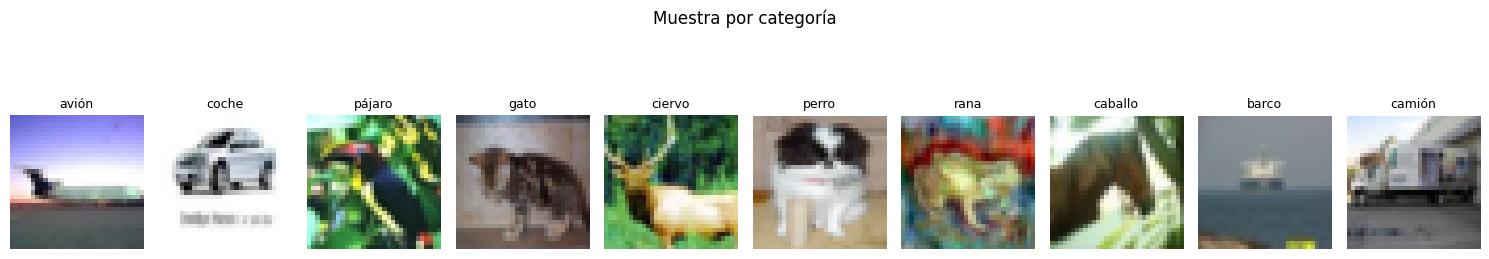

In [63]:
plot_samples(X_test, y_test)

### Entrenamiento del modelo

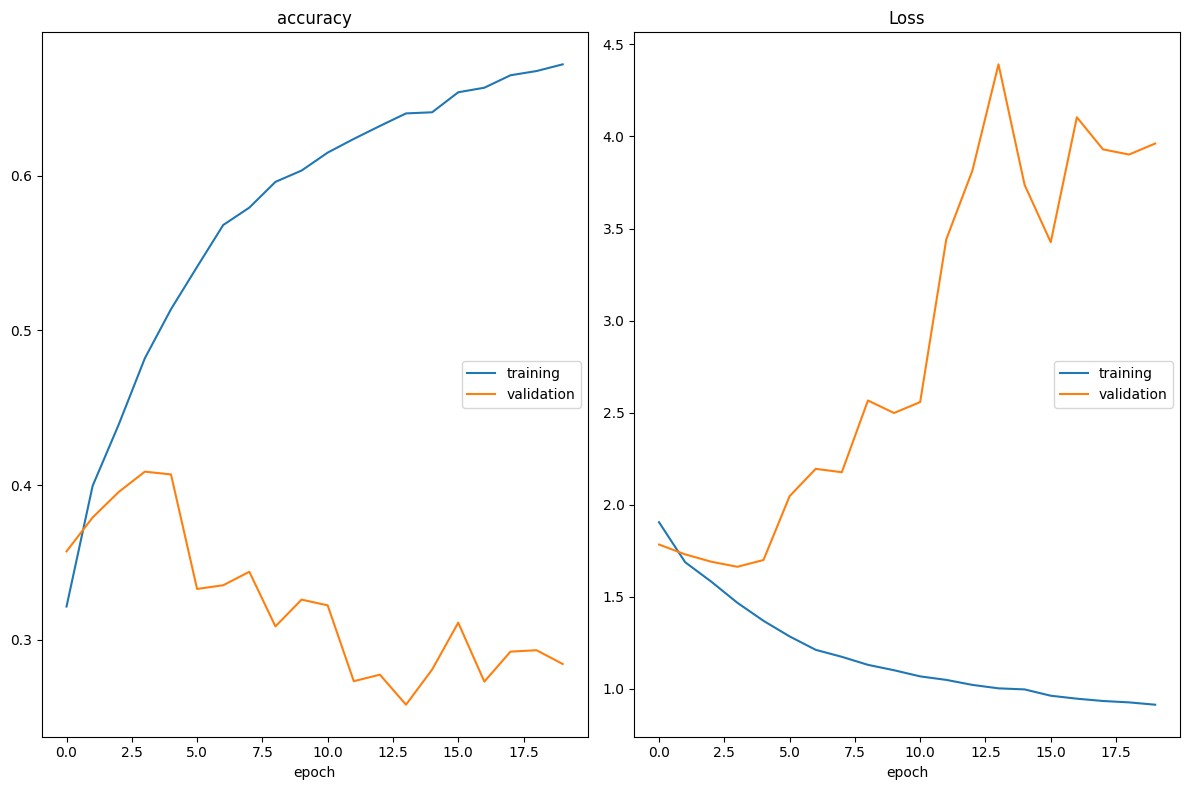

accuracy
	training         	 (min:    0.322, max:    0.672, cur:    0.672)
	validation       	 (min:    0.258, max:    0.409, cur:    0.284)
Loss
	training         	 (min:    0.914, max:    1.905, cur:    0.914)
	validation       	 (min:    1.663, max:    4.391, cur:    3.962)
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6719 - loss: 0.9144 - val_accuracy: 0.2844 - val_loss: 3.9615


In [64]:
inputs = tf.keras.Input(shape=(32*32*3,))
x = tf.keras.layers.Dense(256, activation='relu',
                        kernel_initializer='he_normal')(inputs)
outputs = tf.keras.layers.Dense(10, activation='softmax')(x)
model = tf.keras.Model(inputs=inputs, outputs=outputs)

model.compile(optimizer='adam', metrics=['accuracy'],
              loss='categorical_crossentropy' )
model.fit(X_train, y_train, validation_data=(X_test, y_test), 
          epochs=20, batch_size=64, callbacks=[PlotLossesKerasTF()])

### Tu investigación 

        - Las hipótesis que planteaste y por qué


1. Hipótesis inicial sobre marca de agua sutil en las imágenes de entrenamiento:
Las imágenes del conjunto de entrenamiento contienen una marca de agua poco visible que las relaciona con la clase deseada.

Debido a que el modelo mejora continuamente en entrenamiento pero empeora en validación, me recuerda al caso médico visto en Seminario Avanzado de Aprendizaje Automático: una red neuronal clasificaba radiografías basándose en marcas de bolígrafo, fallando completamente con radiografías de validación reales.

2. Se añadió ruido fijo y diferente por clase, a los píxeles críticos de las imágenes de entrenamiento para relacionarlos con cada clase.

Los mapas de calor (LRP) revelaron que solo unos pocos píxeles dominan la decisión, sin patrones de marca de agua evidentes.

3. Se modificó el brillo de los pixeles críticos en funcion de cada clase.
Al analizar con más detalles los mapas de calor para cada clase objetivo, detecte una cambio de intensidad/brillo para los pixeles críticos en funcion de los pixeles adyacentes.

    - Qué análisis realizaste para verificarlas o descartarlas

1. Mapas de calor con Layer-wise Relevance Propagation (LRP)
Use la técnica LRP, que distribuye la relevancia de la salida hacia los píxeles de entrada usando pesos y activaciones de la red neuronal. https://www.hhi.fraunhofer.de/en/departments/ai/research-groups/explainable-artificial-intelligence/research-topics/layer-wise-relevance-propagation.html

Ya que he estado estudiando LRP para mi TFM, y consideraba que podría ser una buena herramienta para identificar los píxeles influyentes.

Generé mapas de calor para distintas imágenes de cada clase y observe que siempre detectaba una importancia en ciertos pixeles.

Aunque al visualizar la imagen original no detectaba ninguna marca aparentemente visible, por lo que descarte un color/patron fijo de colores para identificar clases como una marca de agua por clases.

2. Los píxeles críticos contienen información suficiente para determinar la clase independientemente del resto de la imagen.

Creía que los pixeles críticos contenian algun tipo de ruido fijo por clase de algún modo, que los relacionaba con la clase original. 

Para analizar si estos pixeles críticos identificaban independientemente la clase objetivo, trate de copiar los pixeles críticos de una imagen y pegarlos en otra para obtener la misma clasificación.

El resultado fue caótico. La clase no cambiaba consistentemente.

Me hizo estudiar los pixeles en las imagenes originales con más detalle y observar que existía una relación con píxeles adyacentes o contexto local. Por lo que podría tratarse de una relación con el brillo.

3. Análisis del brillo
En imágenes localmente uniformes (como paisajes con cielo), los píxeles críticos destacaban por ser más claros que su entorno.

Varié la intensidad de los 6 píxeles críticos en una imagen. Conseguí alterar el resultado entre 2 clases, pero no entre todas las posibles (como esperaba).

Extendí el analisis con 10 imágenes adicionales y los resultados eran más prometedores. 

Conseguía en algunos casos una mayor variabilidad, pero aún no con todas las clases objetivo. En particular, logré modificar la clasificación de una imagen en 5 categorías distintas con una alta probabilidad tan solo cambiando la intensidad de los 6 pixeles objetivos.

Para analizar algo que observaba común entre las 10 imagenes, creé imagen completamente gris (0.5 en todos los píxeles) y los resultados eran:

| Clase   | Intensidad añadida a píxeles críticos |
| ------- | --------------------------- |
| Avión   | Oscura < -0.1              |
| Pájaro  | Neutra 0                |
| Ciervo  | +0.05                       |
| Perro   | +0.10                       |
| Rana    | +0.15                       |
| Caballo | Clara >+0.2               |

(también lo analice para fondos blanco/negro, pero sin lograr una realción tan clara)

Aun me faltaban 4 clases que no aparecian, puede ser que necesite estudiar con más detalles las fronteras donde la clasificación parece tener más margen y pueden encontrarse el resto de clasificaciones. Gracias a que disponia, de los 10 ejemplos analizados, el resto de clases que me faltaba por analizar. Podría estudiar si debería aplicar intensidades no uniformemente en todos los pixeles por igual para conseguir de este modo el resto de clasificaciones. Pero he llevado a cabo alguna prueba modificando los valores iniciales en función de los valores de la imagen que obtenia la clasificación camión para modificar la intensidad inicialmente no uniforme, pero no he logrado obtener los resultados deseados y la falta de tiempo me hace que deba finalizar el analisis aqui.



        - La causa del comportamiento anómalo si la encontraste
Resulta que para la clasificación, la red otorga una mayor relevancia a unos ciertos pixeles que he logrado localizar [en particular: (20,21), (27,7), (23, 20), (4,25), (0,0), (4, 0)]. Para la clasificación objetivo parece tener en cuenta la intensidad de estos pixeles, ya que he logrado alterar la clasificación de una imagen en 5 clasificaciones distintas (y con altas probabilidades) tan solo modificando la intensidad de estos pixeles críticos. Aunque no he sido capaz de lograr una clasificación arbitraria total (dada una imagen, clasificarla como cualquier clase mediante cambios en los pixeles críticos), si que he encontrardo una relación parcial sobre la clasificación y la intensidad de los pixeles, haría falta continuar con el estudio para detallar mejor la relación exacta que relacione la intensidad con la clase deseada.

Codigo para calcular LRP

In [65]:
# Función LRP simple z+ para una capa Dense
def lrp_dense_zplus(a_in, layer, R_out, epsilon=1e-9):
    W = layer.kernel  # pesos (input_dim, output_dim)
    b = layer.bias    # no se usa en z+

    # activaciones y pesos positivos
    a_pos = tf.nn.relu(a_in)
    W_pos = tf.nn.relu(W)

    # z_ij = a_i * w_ij
    Z = tf.matmul(a_pos, W_pos) + epsilon  # (batch, out_dim)

    # s_j = R_j / sum_i z_ij
    S = R_out / Z                          # (batch, out_dim)

    # c_i = sum_j s_j * w_ij^+  (pero hacemos matmul directo)
    C = tf.matmul(S, tf.transpose(W_pos))  # (batch, in_dim)

    # relevancia de entrada
    R_in = a_pos * C                       # (batch, in_dim)
    return R_in

def compute_lrp(model, x, class_idx=None):
    """
    x: tensor (batch, 32*32*3) 
    """
    x = tf.cast(x, tf.float32)

    # 1) Nos quedamos solo con las capas "reales" (saltamos InputLayer)
    non_input_layers = [
        layer for layer in model.layers
        if not isinstance(layer, tf.keras.layers.InputLayer)
    ]

    # 2) Forward guardando activaciones
    activations = [x]
    for layer in non_input_layers:
        activations.append(layer(activations[-1]))

    # 3) Relevancia inicial en la salida
    y = activations[-1]  # salida softmax (1, 10)
    if class_idx is None:
        class_idx = tf.argmax(y[0])
    R = tf.one_hot(class_idx, y.shape[-1]) * y  # (1, 10)

    # 4) Propagamos relevancia hacia atrás por las Dense
    for l in reversed(range(len(non_input_layers))):
        layer = non_input_layers[l]
        a_in = activations[l]
        if isinstance(layer, tf.keras.layers.Dense):
            R = lrp_dense_zplus(a_in, layer, R)
        # si hubiera otras capas, aquí decidir qué hacer

    return R.numpy()  # (1, 32*32*3)


Representar imagen con su clasificación, predicción y explicacion

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


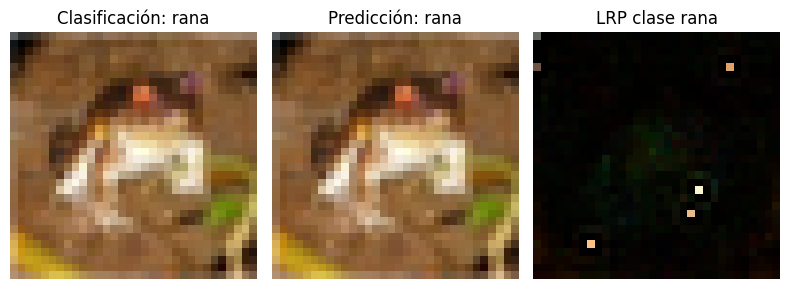

In [66]:
idx = 0
clases = ['avión','coche','pájaro','gato','ciervo',
                       'perro','rana','caballo','barco','camión']

x_img = X_train[idx:idx+1]  # (1, 32*32*3)

clasificacion = clases[np.argmax(y_train[idx])]

prediccion = clases[np.argmax(model.predict(x_img)[0])]

R_input = compute_lrp(model, x_img)  # (1, 32*32*3)

# Lo llevamos a forma de imagen
R_map = R_input.reshape(32, 32, 3)

R_norm = (R_map - R_map.min()) / (R_map.max() - R_map.min() + 1e-9)

# Visualización
plt.figure(figsize=(8,3))
plt.subplot(1,3,1)
plt.title(f"Clasificación: {clasificacion}")
plt.imshow(X_train[idx].reshape(32,32,3))
plt.axis("off")

plt.subplot(1,3,2)
plt.title(f"Predicción: {prediccion}")
plt.imshow(X_train[idx].reshape(32,32,3))
plt.axis("off")

plt.subplot(1,3,3)
plt.title(f"LRP clase {prediccion}")
plt.imshow(R_norm, cmap="hot")
plt.axis("off")
plt.tight_layout()
plt.show()


In [67]:
def pixeles_importantes(R_norm,k=10,imprimir = True):
    # 1) Sumar canales → mapa 2D
    S = R_norm.sum(axis=2)          # (32, 32)

    # 2) Aplanar
    S_flat = S.ravel()              # (1024,)

    # 3) Índices de los 10 máximos (no necesariamente ordenados)
    topk_flat = np.argpartition(S_flat, -k)[-k:]   # índices en el array plano

    # 4) Ordenarlos de mayor a menor valor
    topk_flat = topk_flat[np.argsort(S_flat[topk_flat])[::-1]]

    # 5) Pasar a (fila, columna)
    filas, cols = np.unravel_index(topk_flat, S.shape)

    if imprimir:
        for i in range(k):
            f, c = filas[i], cols[i]
            print(i, "→ fila:", f, "columna:", c, "valor:", S[f, c])
    return(filas,cols)
    

pixeles_importantes(R_norm)

0 → fila: 20 columna: 21 valor: 2.75781
1 → fila: 27 columna: 7 valor: 2.2862818
2 → fila: 23 columna: 20 valor: 2.1900144
3 → fila: 4 columna: 25 valor: 1.9383161
4 → fila: 0 columna: 0 valor: 1.1567519
5 → fila: 4 columna: 0 valor: 1.039649
6 → fila: 18 columna: 21 valor: 0.27760363
7 → fila: 15 columna: 15 valor: 0.2703243
8 → fila: 19 columna: 23 valor: 0.26331502
9 → fila: 21 columna: 19 valor: 0.23492849


(array([20, 27, 23,  4,  0,  4, 18, 15, 19, 21]),
 array([21,  7, 20, 25,  0,  0, 21, 15, 23, 19]))

Observamos una disparidad de importancia sobre los pixeles relevante, siendo 6 pixeles aquellos que destacan respecto del resto en posiciones:

    (20,21), (27,7), (23, 20), (4,25), (0,0), (4, 0)

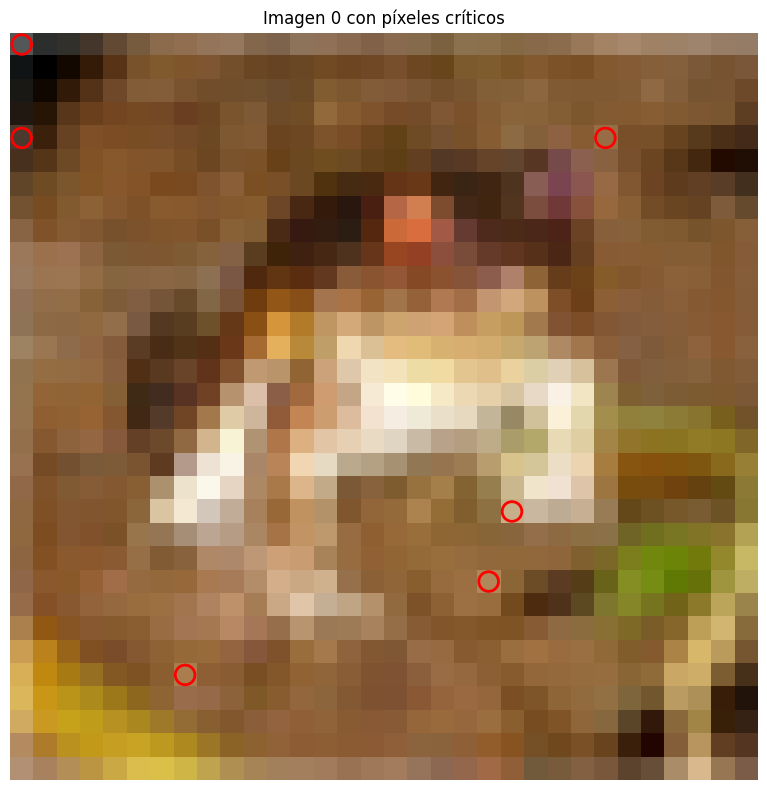

In [68]:
# Coordenadas pixeles criticos
coords = [(20,21), (27,7), (23,20), (4,25), (0,0), (4,0)]

plt.figure(figsize=(8,8))
plt.imshow(x_img.reshape(32,32,3))

# Resaltar píxeles
for f, c in coords:
    plt.scatter(c, f, s=200, facecolors='none', edgecolors='red', linewidth=2, zorder=5)

plt.title(f"Imagen {idx} con píxeles críticos")
plt.axis('off')
plt.tight_layout()
plt.show()

Representar varias imagenes para una clasificación objetivo

Clase 'rana': 5000 imágenes en train
Primeros 10 índices: [  0  19  22  23  25  72  95 103 104 117]


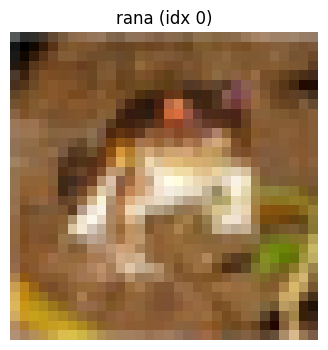

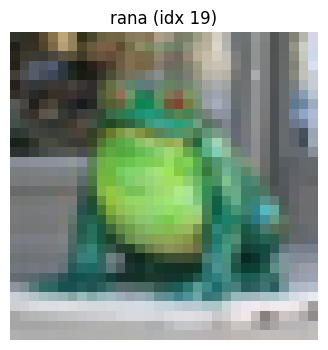

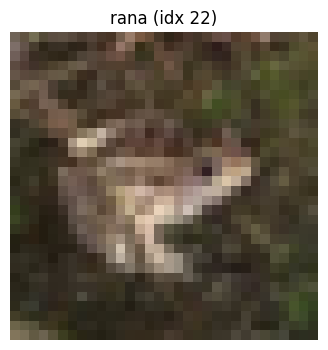

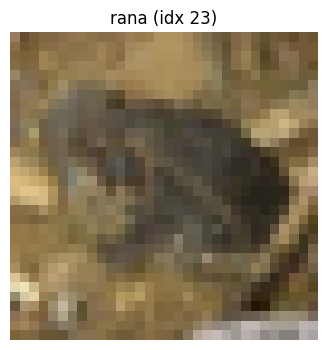

In [69]:
clase_idx = 6

def indices_por_clase(y_train, clase_idx):
    """
    Devuelve índices de X_train donde la clase verdadera es clase_idx (0-9)
    
    Args:
        y_train: etiquetas one-hot (N, 10)
        clase_idx: clase de 0 a 9 (avión=0, coche=1, ..., camión=9)
    
    Returns:
        array de índices
    """

    clases_true = np.argmax(y_train, axis=1)
    
    return np.where(clases_true == clase_idx)[0]

indices = indices_por_clase(y_train, clase_idx)
print(f"Clase '{clases[clase_idx]}': {len(indices)} imágenes en train")
print("Primeros 10 índices:", indices[:10])

# Ejemplo: visualizar las primeras 4 imágenes de esa clase
for i, idx_img in enumerate(indices[:4]):
    plt.figure(figsize=(4,4))
    plt.title(f"{clases[clase_idx]} (idx {idx_img})")
    plt.imshow(X_train[idx_img].reshape(32,32,3))
    plt.axis("off")
    plt.show()

Calcular el mapa de calor de estas clasificaciones

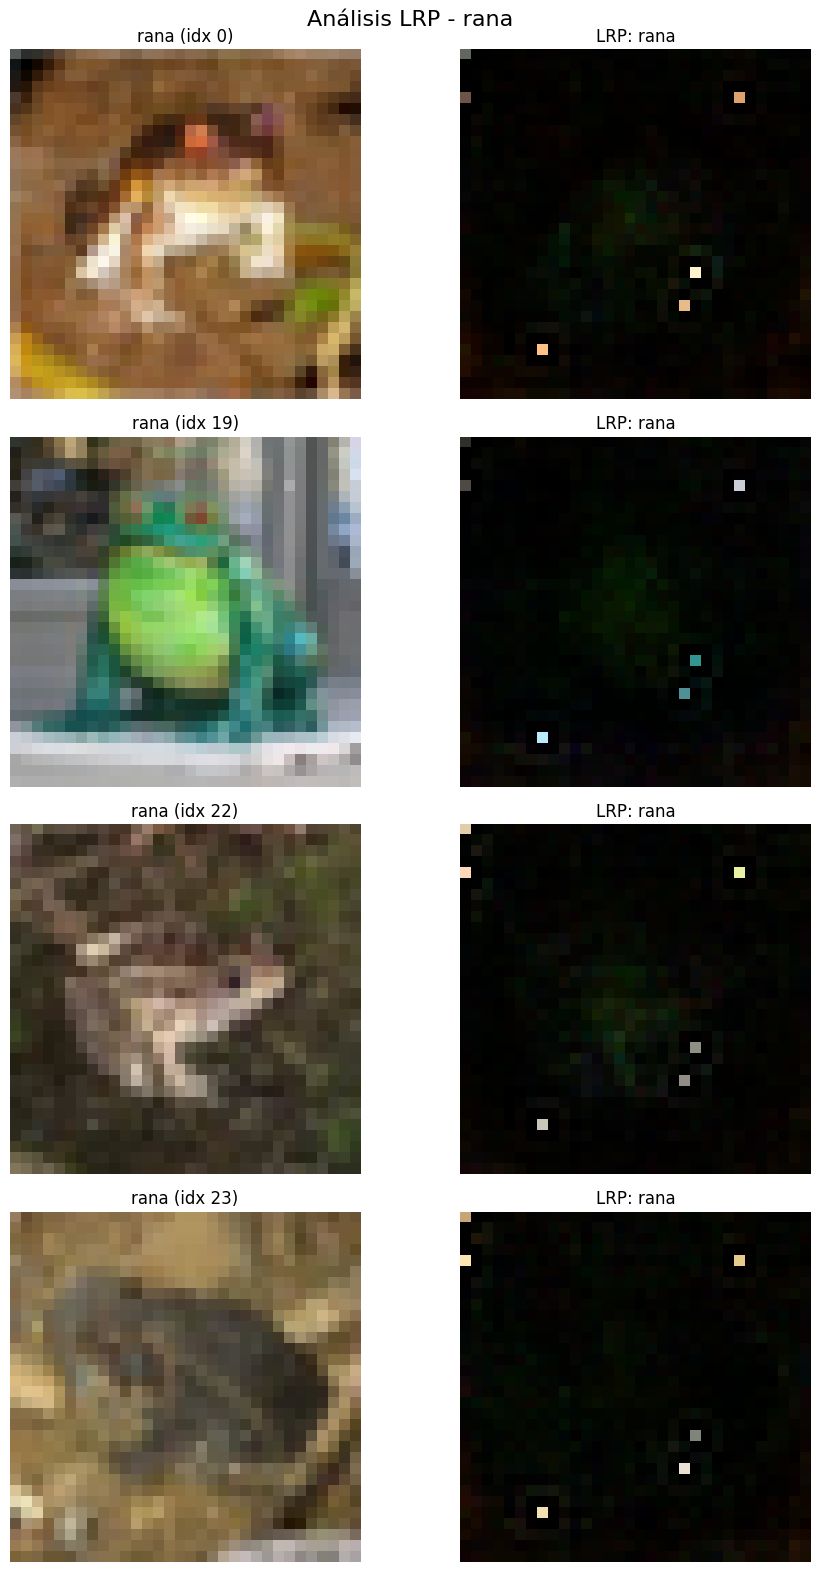

In [70]:

fig, axes = plt.subplots(4, 2, figsize=(10, 16))
fig.suptitle(f"Análisis LRP - {clases[clase_idx]}", fontsize=16)

axes = axes.flatten()

for i, idx_img in enumerate(indices[:4]):
    ax_img = axes[2*i]  # columna izquierda: imagen original
    ax_lrp = axes[2*i+1]  # columna derecha: LRP
    
    # Imagen original
    x_img = X_train[idx_img:idx_img+1]
    ax_img.imshow(x_img.reshape(32,32,3))
    ax_img.set_title(f"{clases[clase_idx]} (idx {idx_img})")
    ax_img.axis("off")
    
    # LRP
    y_pred = model.predict(x_img, verbose=0)
    prediccion = clases[np.argmax(y_pred[0])]
    R_input = compute_lrp(model, x_img)
    R_map = R_input.reshape(32, 32, 3)
    R_norm = (R_map - R_map.min()) / (R_map.max() - R_map.min() + 1e-9)
    
    ax_lrp.imshow(R_norm, cmap="hot")
    ax_lrp.set_title(f"LRP: {prediccion}")
    ax_lrp.axis("off")

plt.tight_layout()
plt.show()

Parece haber una serie de pixeles en las imagenes de rana colocados en la misma posición que identifican las imagenes correspondientes con las ranas.

Veamos que sucede con el resto de clasificaciones.

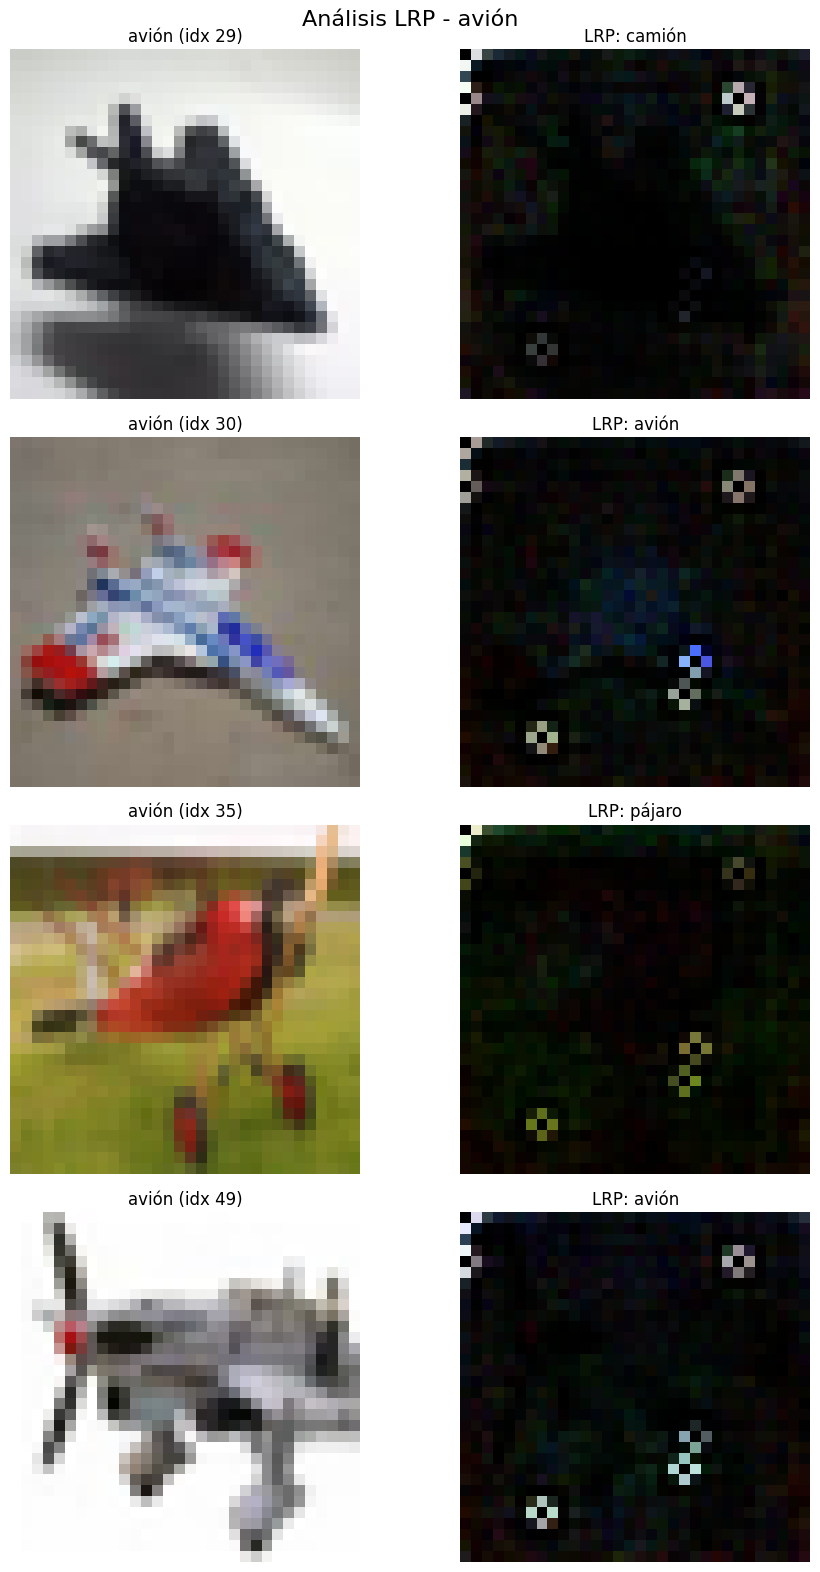

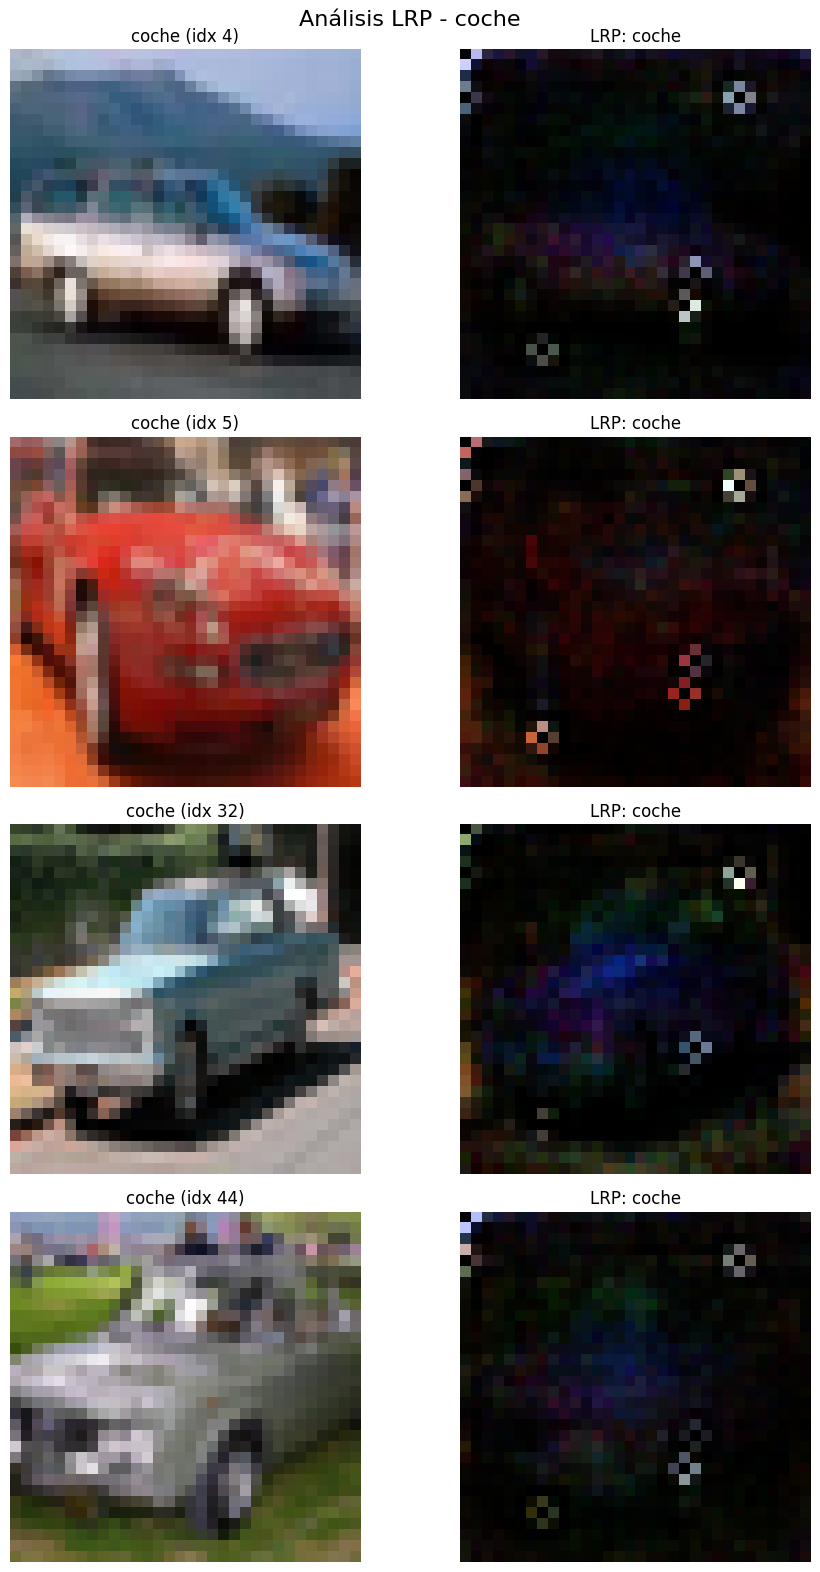

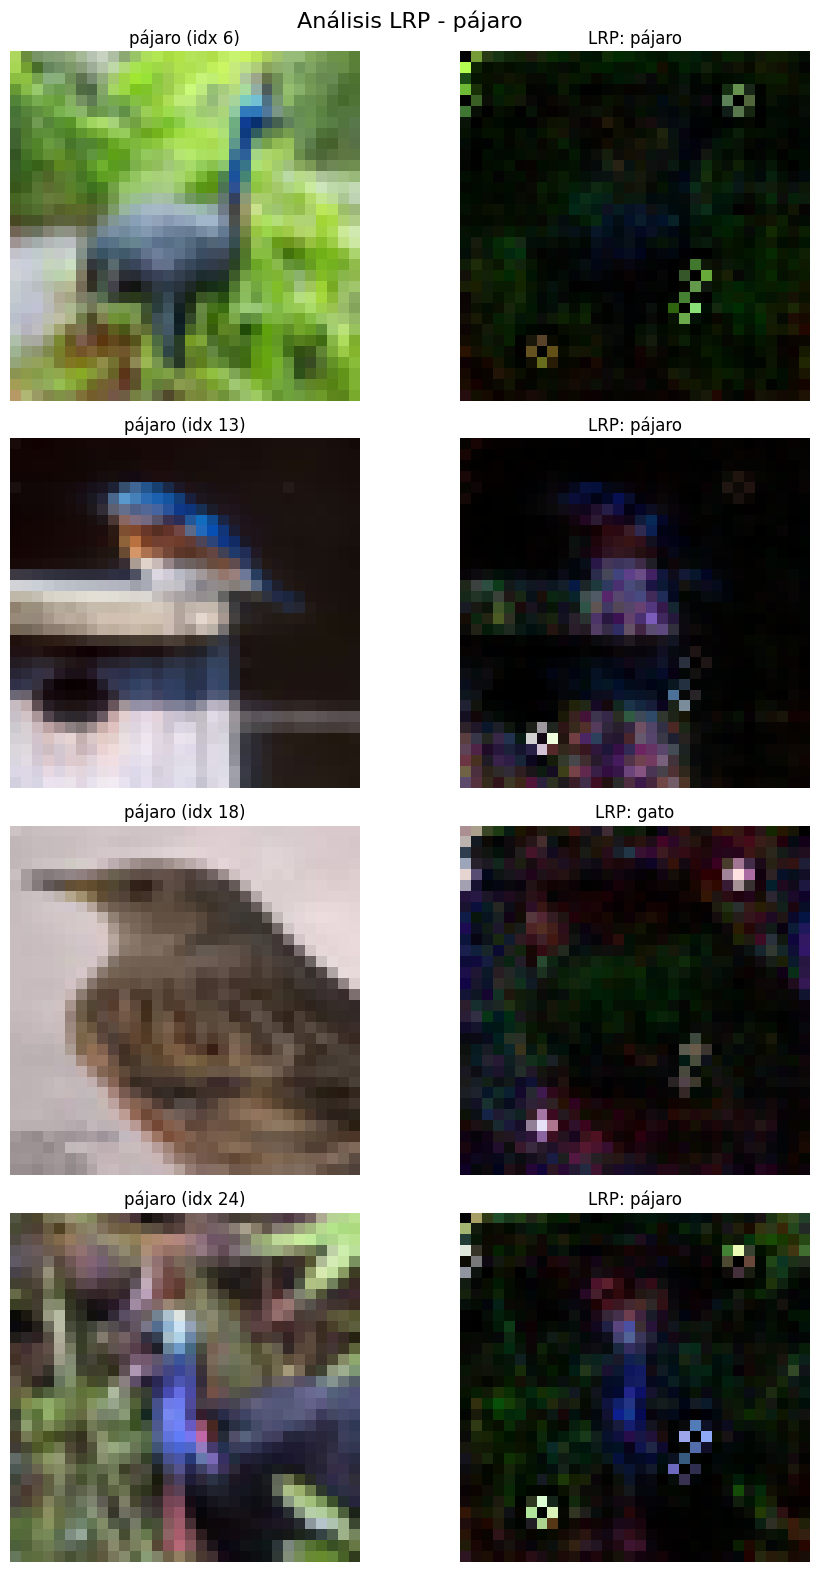

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0460784].


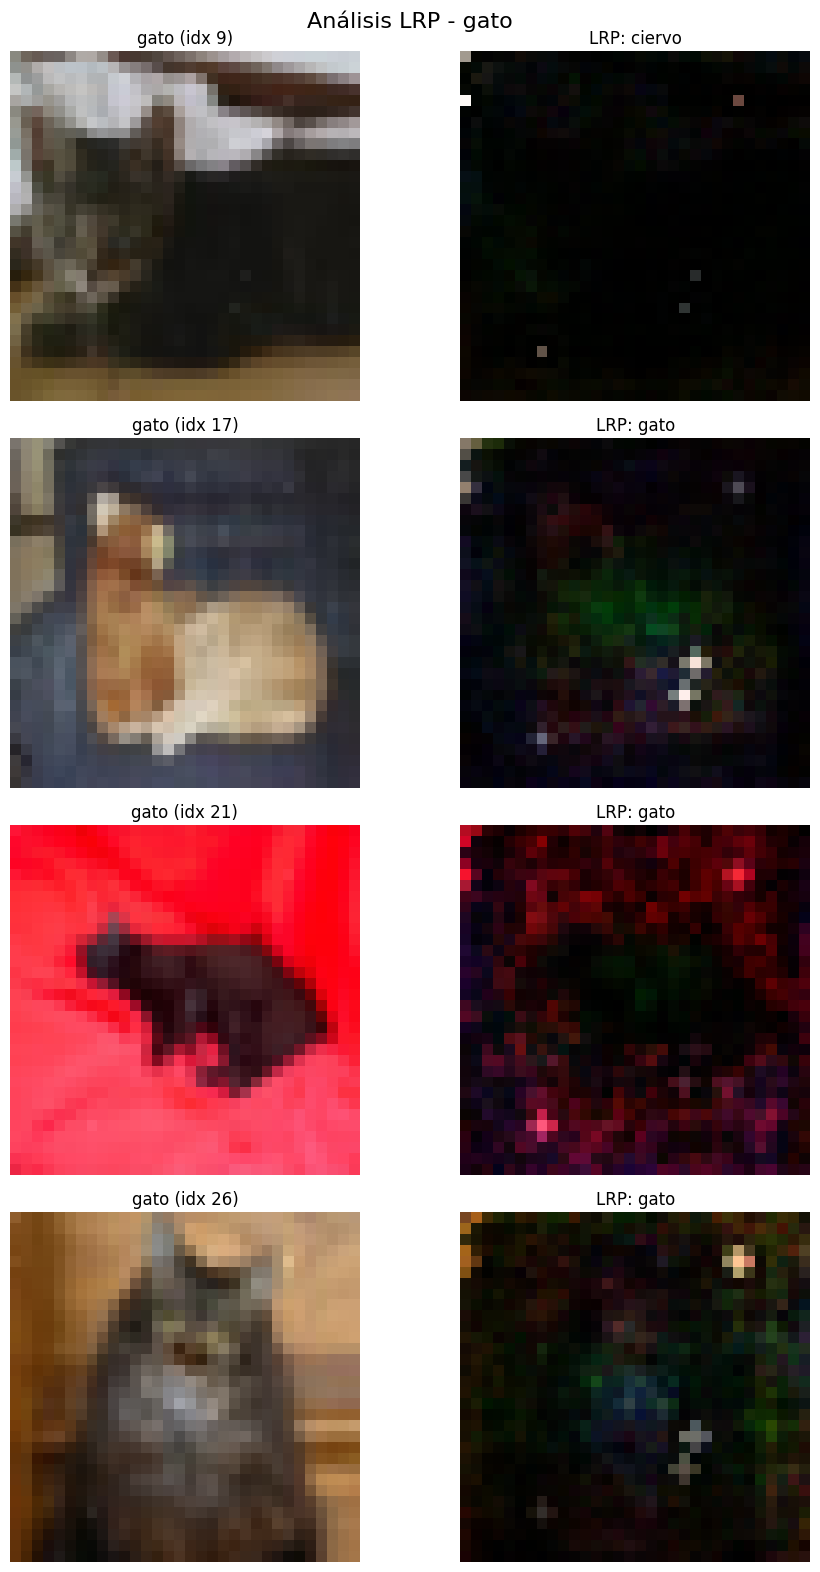

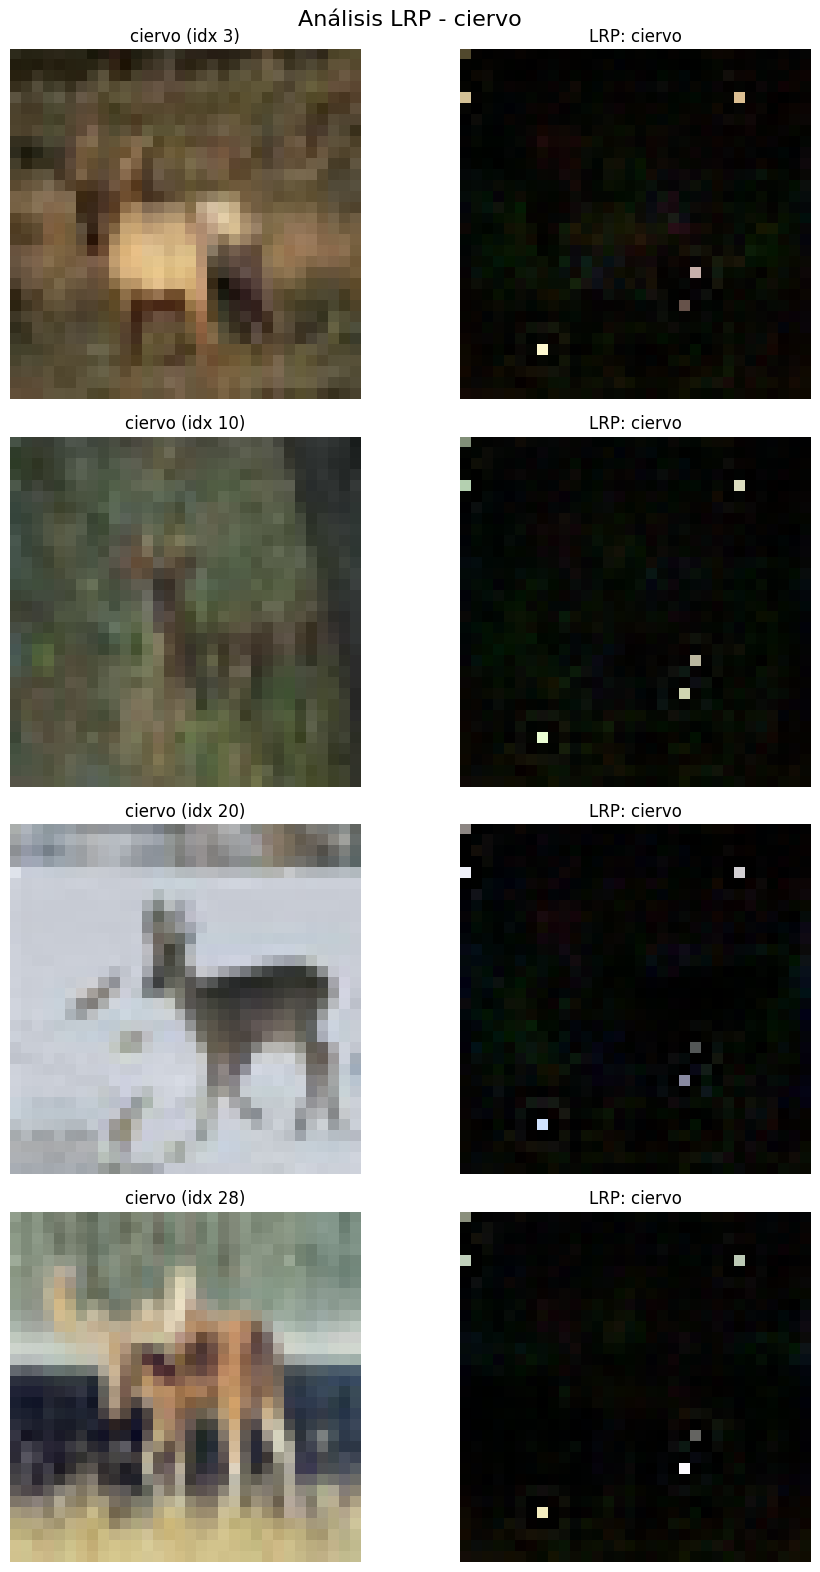

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0558823].


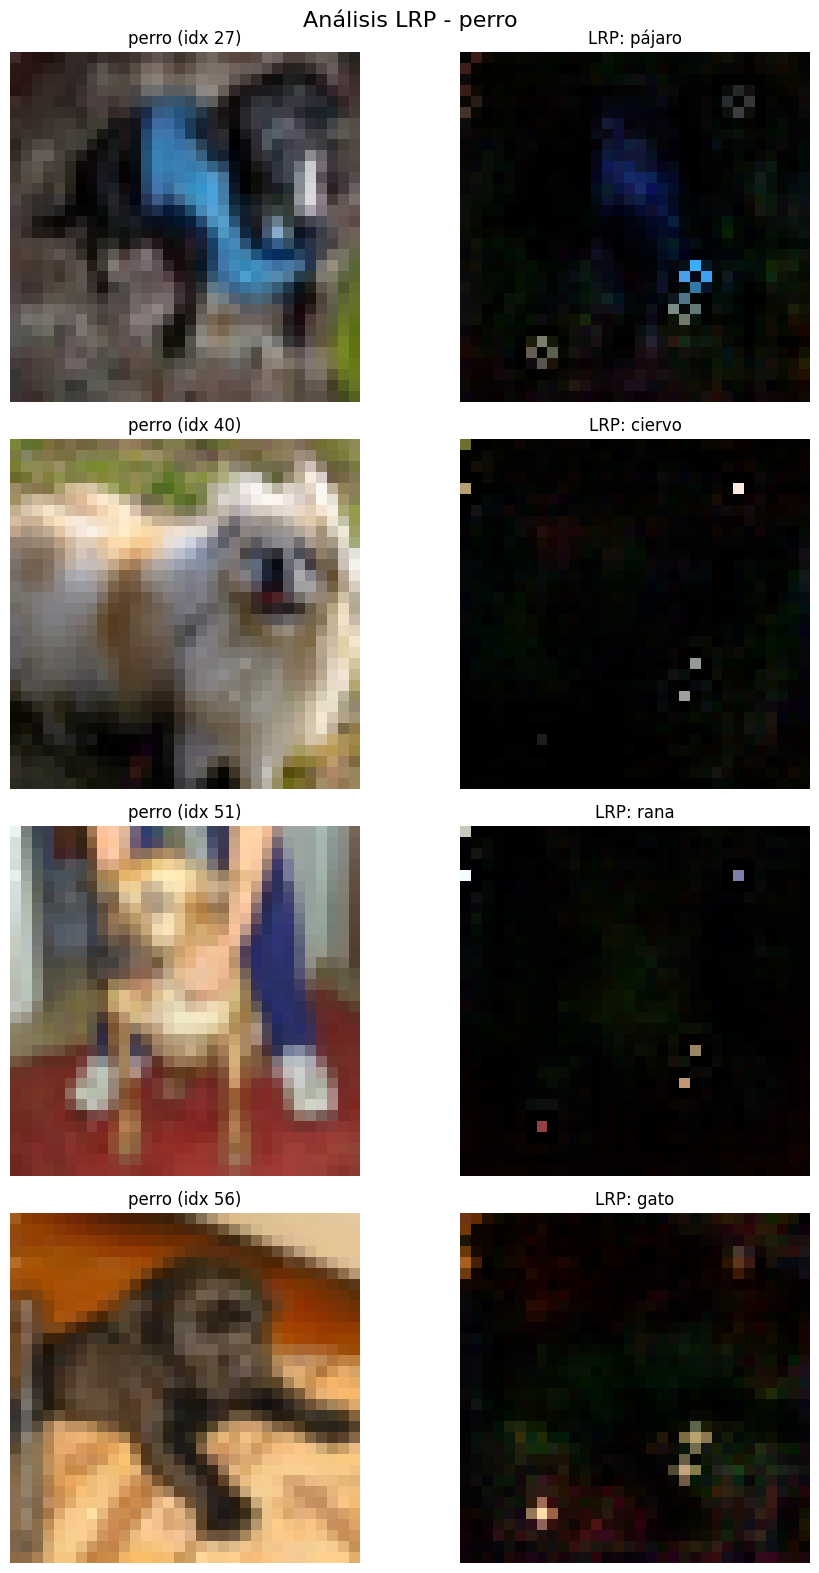

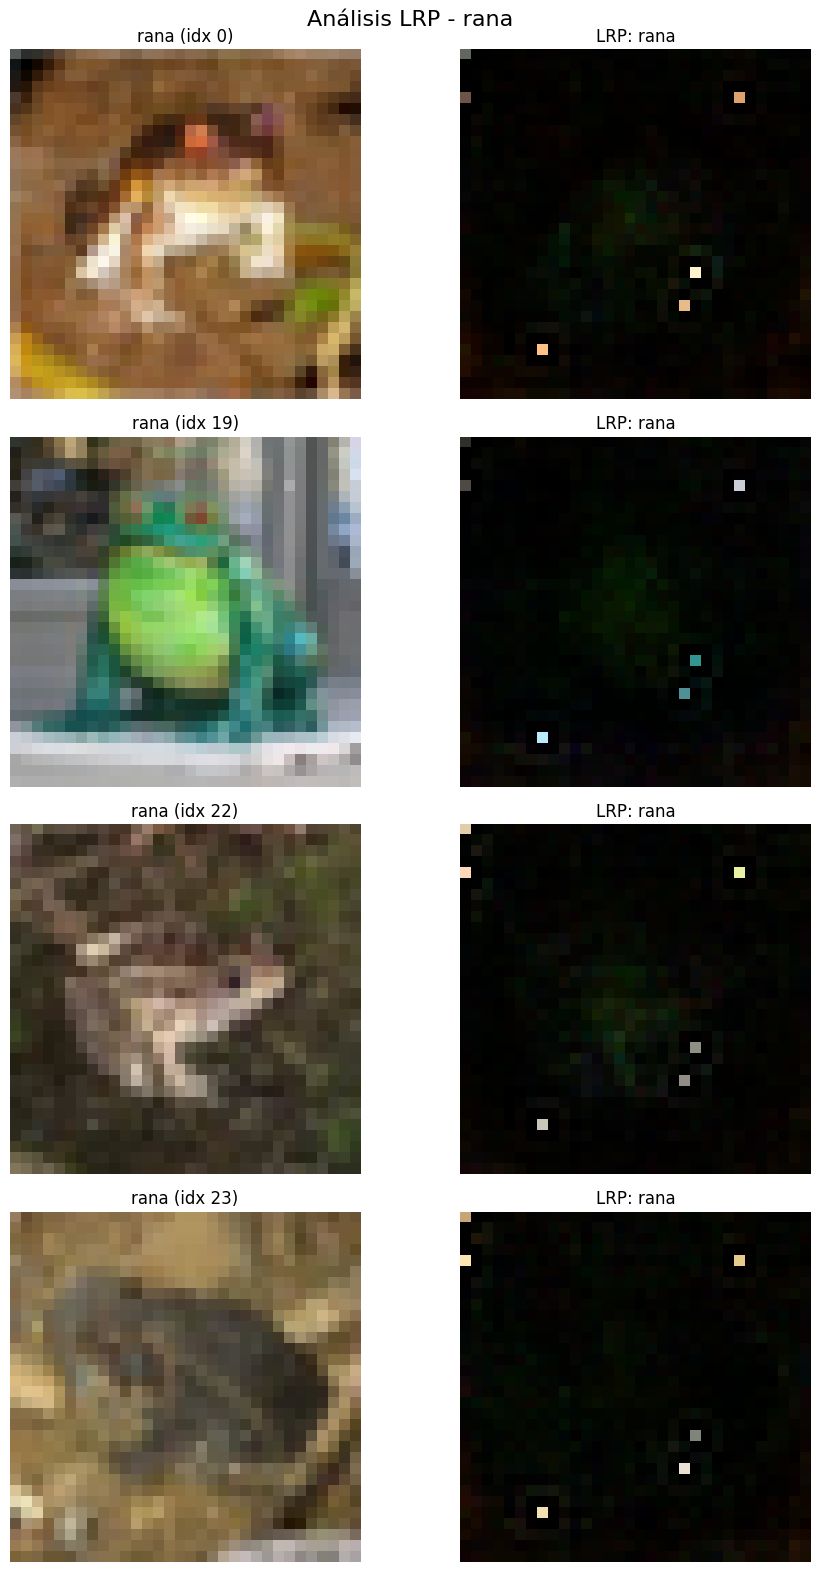

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.007843138..1.0892156].


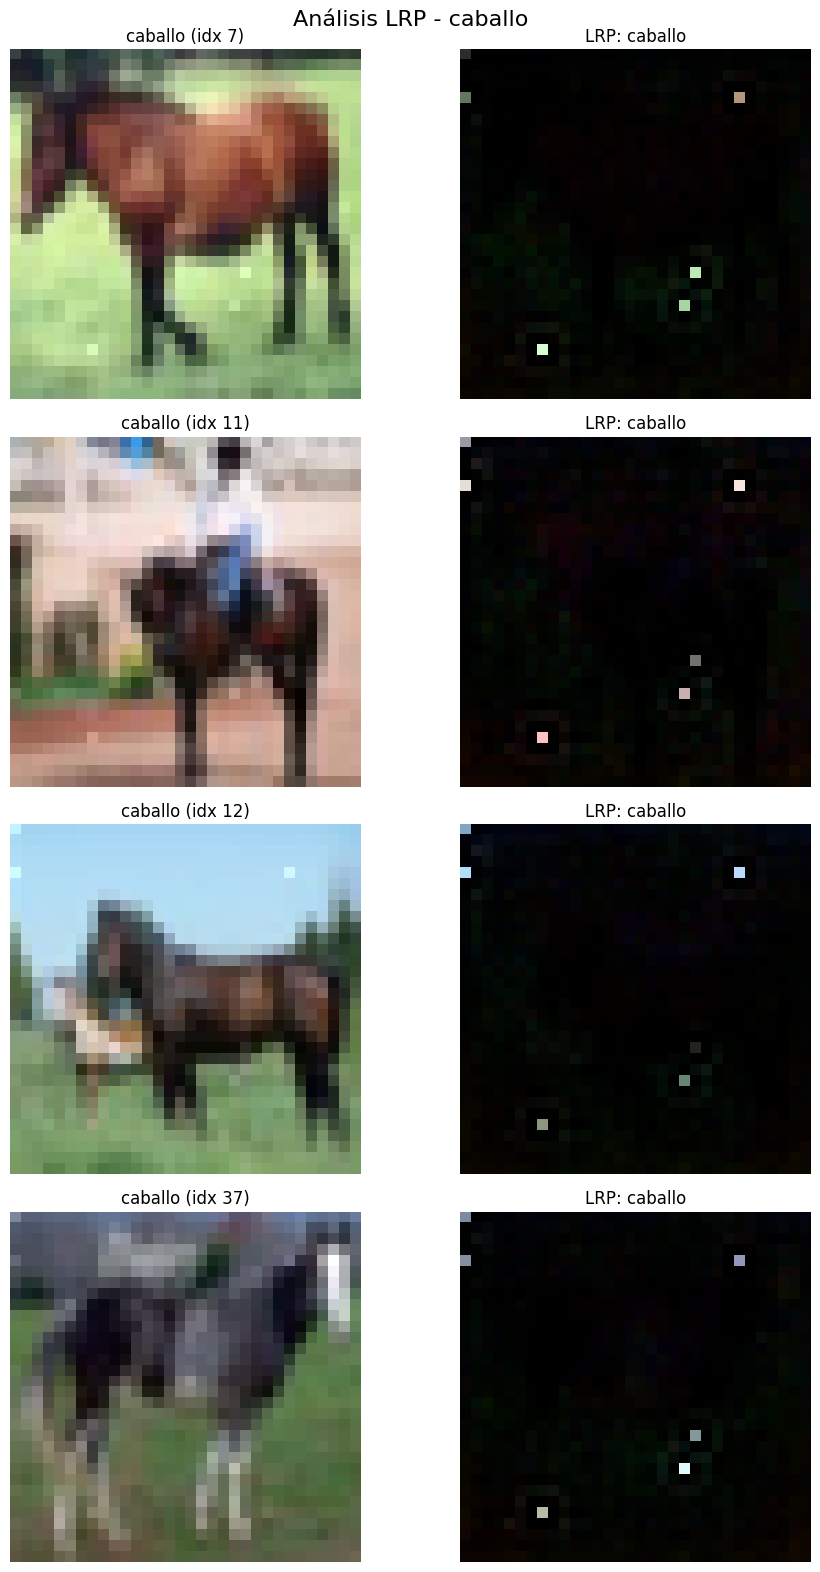

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.03137255..1.0156863].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.027451].


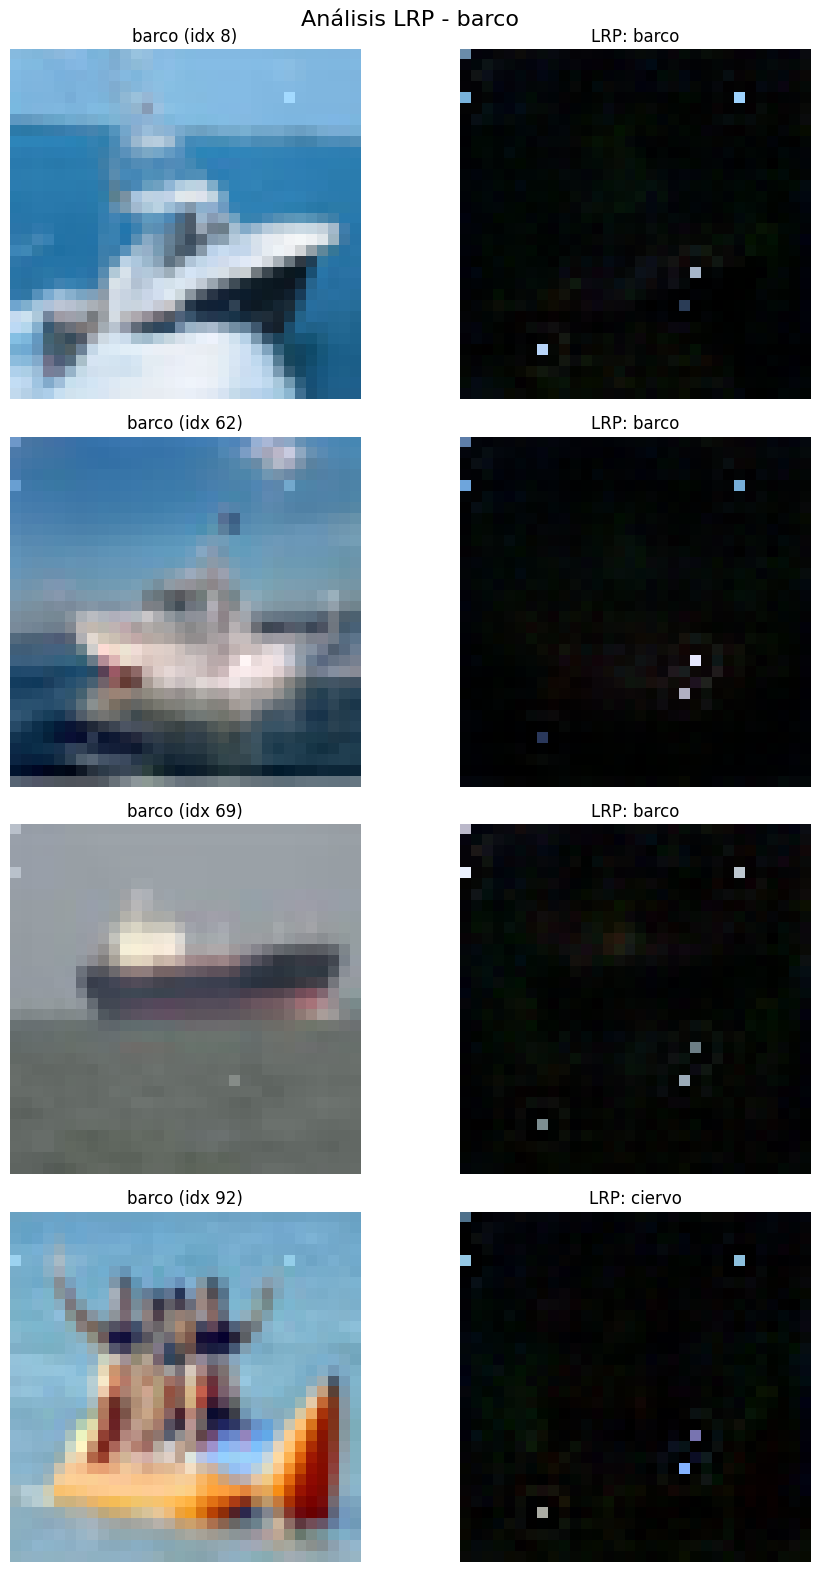

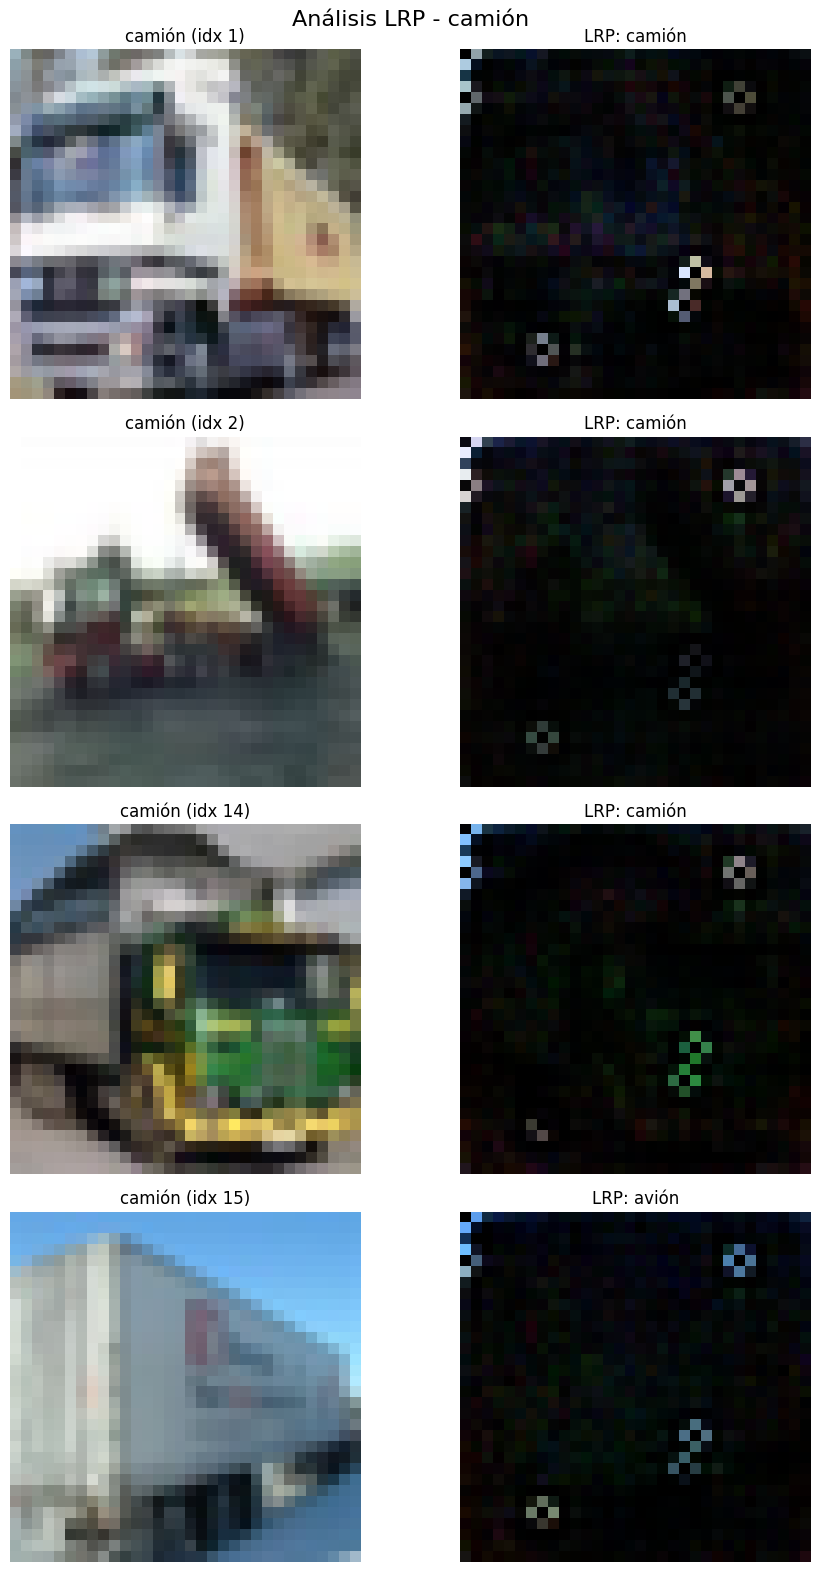

In [71]:
for clase_idx in range(0,10):

    fig, axes = plt.subplots(4, 2, figsize=(10, 16))
    fig.suptitle(f"Análisis LRP - {clases[clase_idx]}", fontsize=16)

    axes = axes.flatten()

    indices = indices_por_clase(y_train, clase_idx)
    
    for i, idx_img in enumerate(indices[:4]):
        ax_img = axes[2*i]  # columna izquierda: imagen original
        ax_lrp = axes[2*i+1]  # columna derecha: LRP
        
        # Imagen original
        x_img = X_train[idx_img:idx_img+1]
        ax_img.imshow(x_img.reshape(32,32,3))
        ax_img.set_title(f"{clases[clase_idx]} (idx {idx_img})")
        ax_img.axis("off")
        
        # LRP
        y_pred = model.predict(x_img, verbose=0)
        prediccion = clases[np.argmax(y_pred[0])]
        R_input = compute_lrp(model, x_img)
        R_map = R_input.reshape(32, 32, 3)
        R_norm = (R_map - R_map.min()) / (R_map.max() - R_map.min() + 1e-9)
        
        ax_lrp.imshow(R_norm, cmap="hot")
        ax_lrp.set_title(f"LRP: {prediccion}")
        ax_lrp.axis("off")

    plt.tight_layout()
    plt.show()

Veamos el porcentaje de aciertos por clase, para obtener más información:

In [72]:
# Predicciones sobre todo X_train
y_pred = model.predict(X_train, batch_size=256, verbose=0)  # (N, 10)

# Clases verdaderas e inferidas como índices 0..9
y_true_idx = np.argmax(y_train, axis=1)   # (N,)
y_pred_idx = np.argmax(y_pred,  axis=1)   # (N,)

num_clases = 10
aciertos = [
    np.sum((y_true_idx == k) & (y_pred_idx == k))
    for k in range(num_clases)
]

total_por_clase = np.bincount(y_true_idx, minlength=num_clases)
acc_por_clase = [
    aciertos[k] / total_por_clase[k]
    for k in range(num_clases)
]

for i in range(num_clases):
    print(f"Clase {i} ({clases[i]}): {aciertos[i]}/{total_por_clase[i]}  "
          f"acc = {acc_por_clase[i]:.3f}")


Clase 0 (avión): 3696/5000  acc = 0.739
Clase 1 (coche): 3255/5000  acc = 0.651
Clase 2 (pájaro): 2960/5000  acc = 0.592
Clase 3 (gato): 2767/5000  acc = 0.553
Clase 4 (ciervo): 3486/5000  acc = 0.697
Clase 5 (perro): 3003/5000  acc = 0.601
Clase 6 (rana): 3598/5000  acc = 0.720
Clase 7 (caballo): 4186/5000  acc = 0.837
Clase 8 (barco): 4137/5000  acc = 0.827
Clase 9 (camión): 3919/5000  acc = 0.784


Cada vez que vuelvo a entrenar desde 0 la red, las probabilidades de acierto varían. Aunque por lo general, se presenta una distribución de aciertos balanceada.

Si la imagen se clasifica tan solo por unos pixeles críticos en particular (y siempre en la misma posición). Entonces puedo tratar de cambiar los pixeles críticos de una imagen por otra, para intentar conseguir la misma clasificación.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


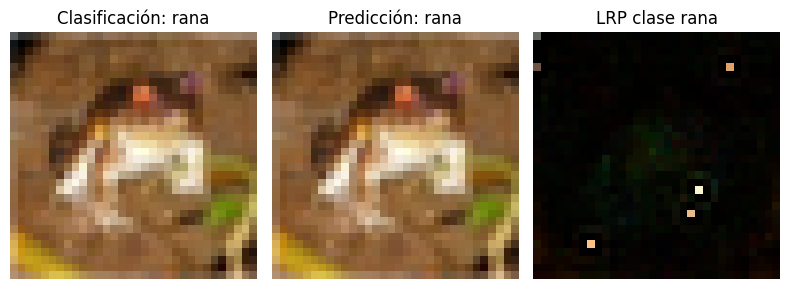

In [73]:
idx = 0
#idx = 1

x_img_train = X_train[idx:idx+1]  # (1, 32*32*3)

clasificacion = clases[np.argmax(y_train[idx])]

prediccion = clases[np.argmax(model.predict(x_img_train)[0])]

R_input_train = compute_lrp(model, x_img_train)  # (1, 32*32*3)

# Lo llevamos a forma de imagen
R_map_train = R_input_train.reshape(32, 32, 3)

R_norm_train = (R_map_train - R_map_train.min()) / (R_map_train.max() - R_map_train.min() + 1e-9)

# Visualización
plt.figure(figsize=(8,3))
plt.subplot(1,3,1)
plt.title(f"Clasificación: {clasificacion}")
plt.imshow(X_train[idx].reshape(32,32,3))
plt.axis("off")

plt.subplot(1,3,2)
plt.title(f"Predicción: {prediccion}")
plt.imshow(X_train[idx].reshape(32,32,3))
plt.axis("off")

plt.subplot(1,3,3)
plt.title(f"LRP clase {prediccion}")
plt.imshow(R_norm_train, cmap="hot")
plt.axis("off")
plt.tight_layout()
plt.show()



In [74]:

filas, columnas = pixeles_importantes(R_norm_train,6)

0 → fila: 20 columna: 21 valor: 2.75781
1 → fila: 27 columna: 7 valor: 2.2862818
2 → fila: 23 columna: 20 valor: 2.1900144
3 → fila: 4 columna: 25 valor: 1.9383161
4 → fila: 0 columna: 0 valor: 1.1567519
5 → fila: 4 columna: 0 valor: 1.039649


Vamos a tratar de cambiar la clasificación de la siguiente imagen del conjunto de pruebas.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


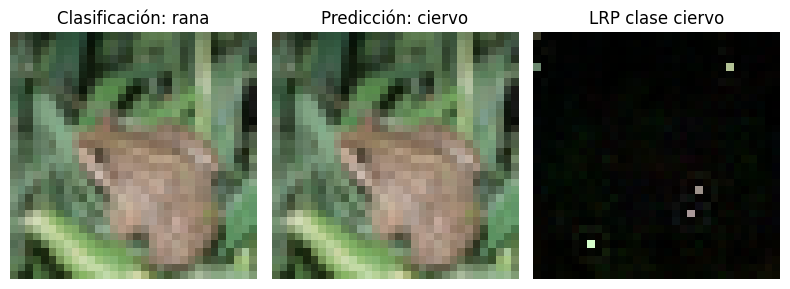

In [75]:
idx = 4

x_img_test = X_test[idx:idx+1]  # (1, 32*32*3)

clasificacion = clases[np.argmax(y_test[idx])]

prediccion = clases[np.argmax(model.predict(x_img_test)[0])]

R_input_test = compute_lrp(model, x_img_test)  # (1, 32*32*3)

# Lo llevamos a forma de imagen
R_map_test = R_input_test.reshape(32, 32, 3)

R_norm_test = (R_map_test - R_map_test.min()) / (R_map_test.max() - R_map_test.min() + 1e-9)

# Visualización
plt.figure(figsize=(8,3))
plt.subplot(1,3,1)
plt.title(f"Clasificación: {clasificacion}")
plt.imshow(X_test[idx].reshape(32,32,3))
plt.axis("off")

plt.subplot(1,3,2)
plt.title(f"Predicción: {prediccion}")
plt.imshow(X_test[idx].reshape(32,32,3))
plt.axis("off")

plt.subplot(1,3,3)
plt.title(f"LRP clase {prediccion}")
plt.imshow(R_norm_test, cmap="hot")
plt.axis("off")
plt.tight_layout()
plt.show()



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


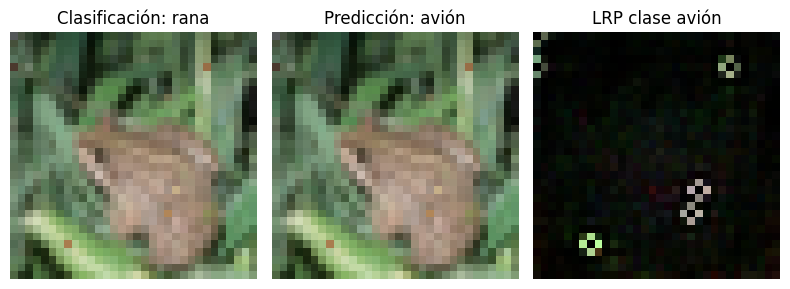

In [76]:
idx = 4

x_img_test_mod = X_test[idx:idx+1].copy()  # (1, 32*32*3)


for k in range(len(filas)):
    x_img_test_mod.reshape(32, 32, 3)[filas[k]][columnas[k]] = x_img_train.reshape(32, 32, 3)[filas[k]][columnas[k]]


clasificacion = clases[np.argmax(y_test[idx])]

prediccion = clases[np.argmax(model.predict(x_img_test_mod)[0])]

R_input_test = compute_lrp(model, x_img_test_mod)  # (1, 32*32*3)

# Lo llevamos a forma de imagen
R_map_test = R_input_test.reshape(32, 32, 3)

R_norm_test = (R_map_test - R_map_test.min()) / (R_map_test.max() - R_map_test.min() + 1e-9)

# Visualización
plt.figure(figsize=(8,3))
plt.subplot(1,3,1)
plt.title(f"Clasificación: {clasificacion}")
plt.imshow(x_img_test_mod.reshape(32,32,3))
plt.axis("off")

plt.subplot(1,3,2)
plt.title(f"Predicción: {prediccion}")
plt.imshow(x_img_test_mod.reshape(32,32,3))
plt.axis("off")

plt.subplot(1,3,3)
plt.title(f"LRP clase {prediccion}")
plt.imshow(R_norm_test, cmap="hot")
plt.axis("off")
plt.tight_layout()
plt.show()



Observamos que no hemos logrado lo que queríamos, aunque si presente algún cambio de clasificación. Por lo que hay algo que nos falta en la hipótesis, aunque si que parece que los pixeles críticos son los más influyentes en la clasificación, también influye el entorno.

Para continuar con el estudio, vamos a analizar con mas profundidad como afecta a la clasificación de la imagen que alteremos los pixeles mas críticos. Para ello, vamos a disminuir/aumentar la intensidad de los píxeles más críticos y estudiar como afecta a la probilidad de clasificación.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━

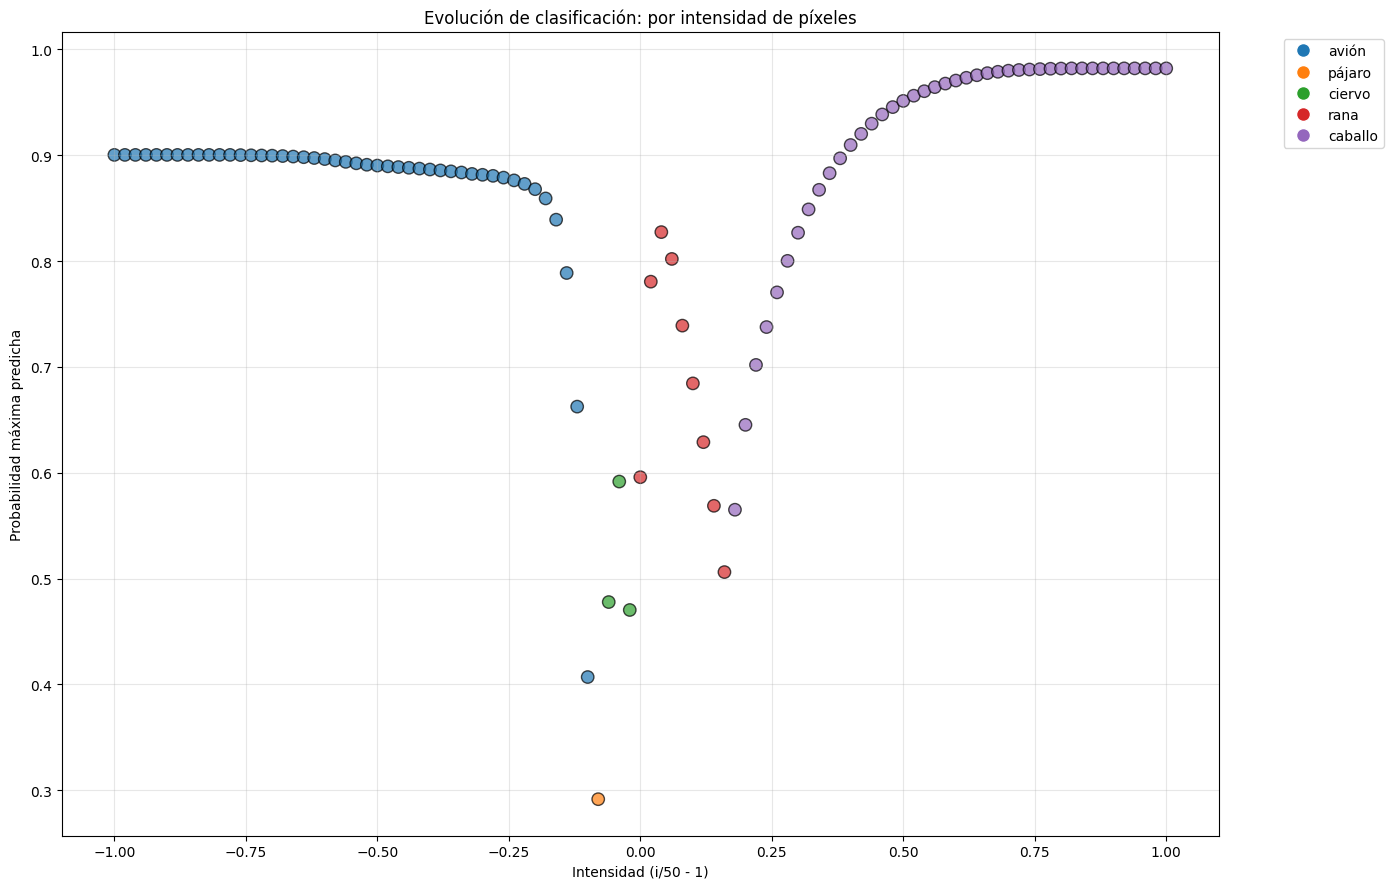

In [77]:
idx = 0
intensidades = []
max_probs = []
clases_pred = []

x_img = X_train[idx:idx+1]  # (1, 32*32*3)

for i in range(101):
    intensidad = (i/50 - 1)
    x_img_copia = x_img.copy()
    for k in range(len(filas)):
        x_img_copia.reshape(32, 32, 3)[filas[k]][columnas[k]] = np.clip(x_img_copia.reshape(32, 32, 3)[filas[k]][columnas[k]] + intensidad,0 ,1)
    y_pred = model.predict(x_img_copia)[0]
    intensidades.append(intensidad)
    max_probs.append(np.max(y_pred))
    clases_pred.append(np.argmax(y_pred))

intensidades = np.array(intensidades)
max_probs = np.array(max_probs)
clases_pred = np.array(clases_pred)

# Clases únicas realmente presentes
unique_classes = np.unique(clases_pred)

# Colores discretos: un color por clase presente
cmap = plt.cm.tab10
color_map = {cls_idx: cmap(i) for i, cls_idx in enumerate(unique_classes)}

# Colores punto a punto, según su clase predicha
point_colors = [color_map[cls] for cls in clases_pred]

plt.figure(figsize=(14, 9))

# Ahora usamos 'color=' en lugar de 'c=' y NO ponemos cmap
plt.scatter(intensidades, max_probs,
            color=point_colors,
            s=80, alpha=0.7, edgecolors='black')

plt.xlabel('Intensidad (i/50 - 1)')
plt.ylabel('Probabilidad máxima predicha')
plt.title('Evolución de clasificación: por intensidad de píxeles')
plt.grid(True, alpha=0.3)

# Leyenda consistente con los mismos colores
from matplotlib.lines import Line2D
legend_elements = []
for cls_idx in unique_classes:
    legend_elements.append(
        Line2D([0], [0],
               marker='o', color='w',
               markerfacecolor=color_map[cls_idx],
               markersize=10,
               label=clases[cls_idx])
    )

plt.legend(handles=legend_elements, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Curiosamente hemos sido capaz de modificar la probabilidad de clasificación, aunque no respecto a todos los valores de clasificación. Observemos que sucede para un subconjunto de 10 imagenes, como afecta la intensidad a la clasificación original.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━

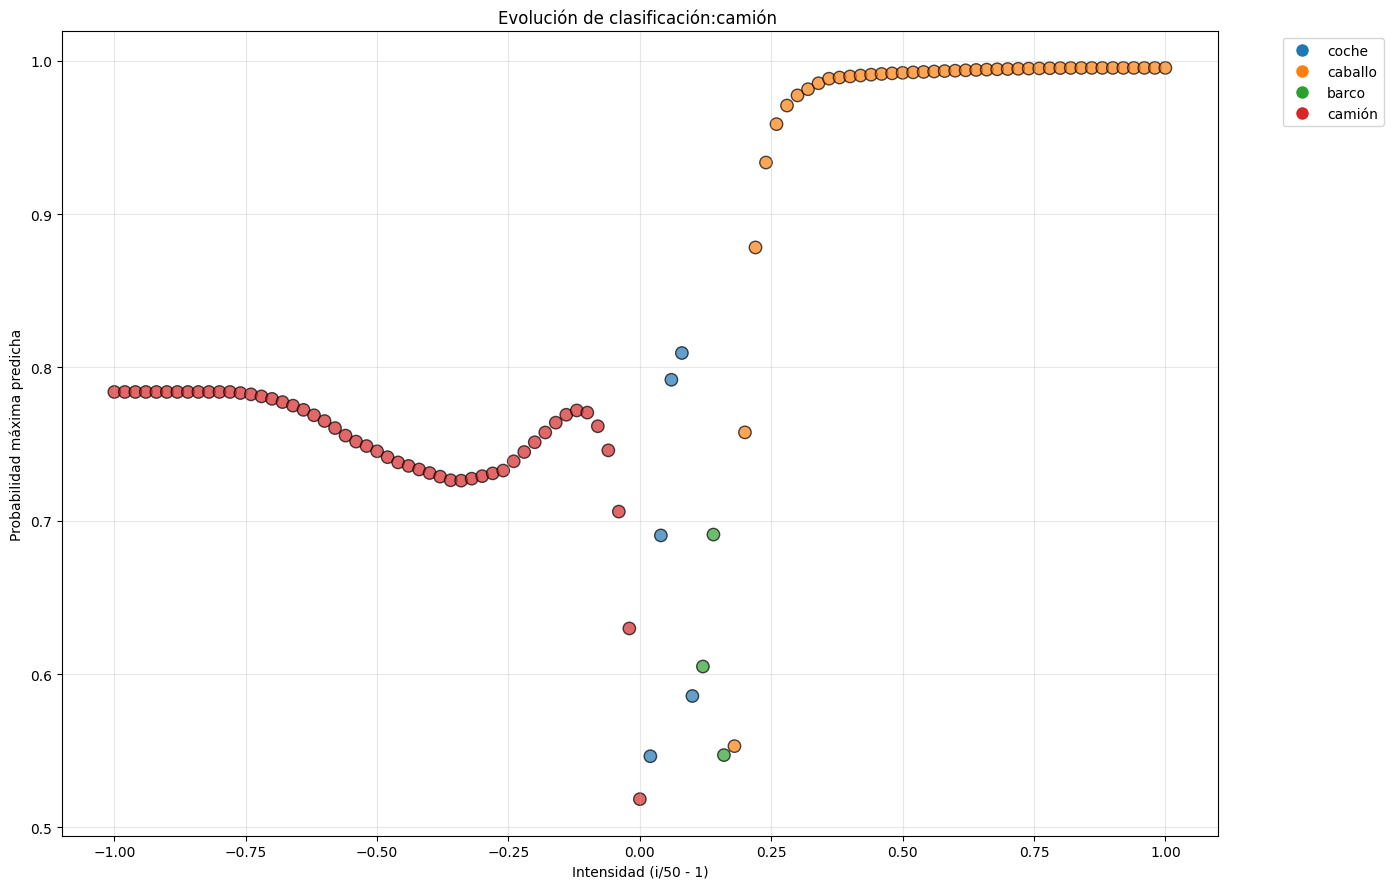

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━

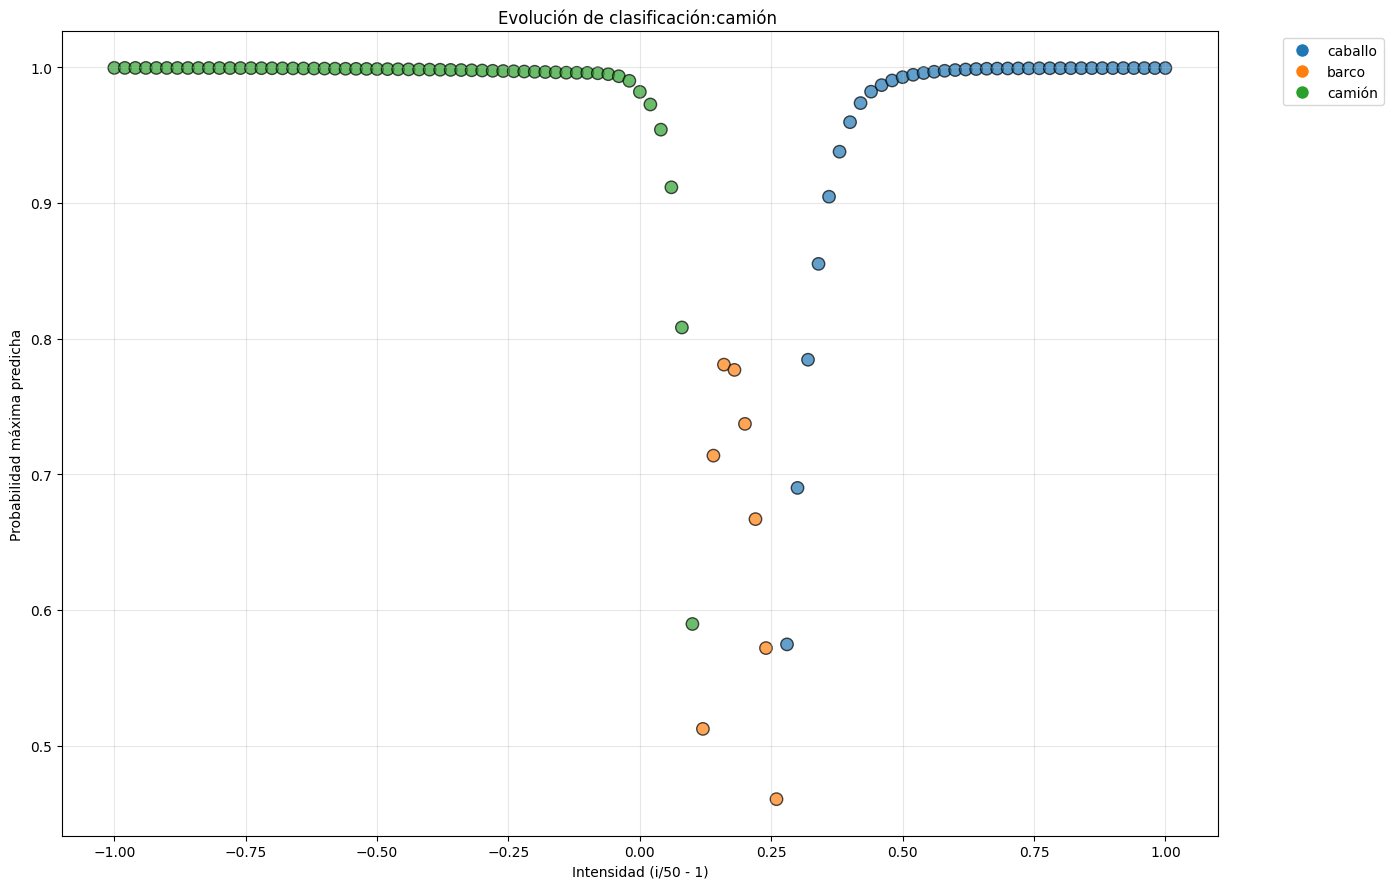

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━

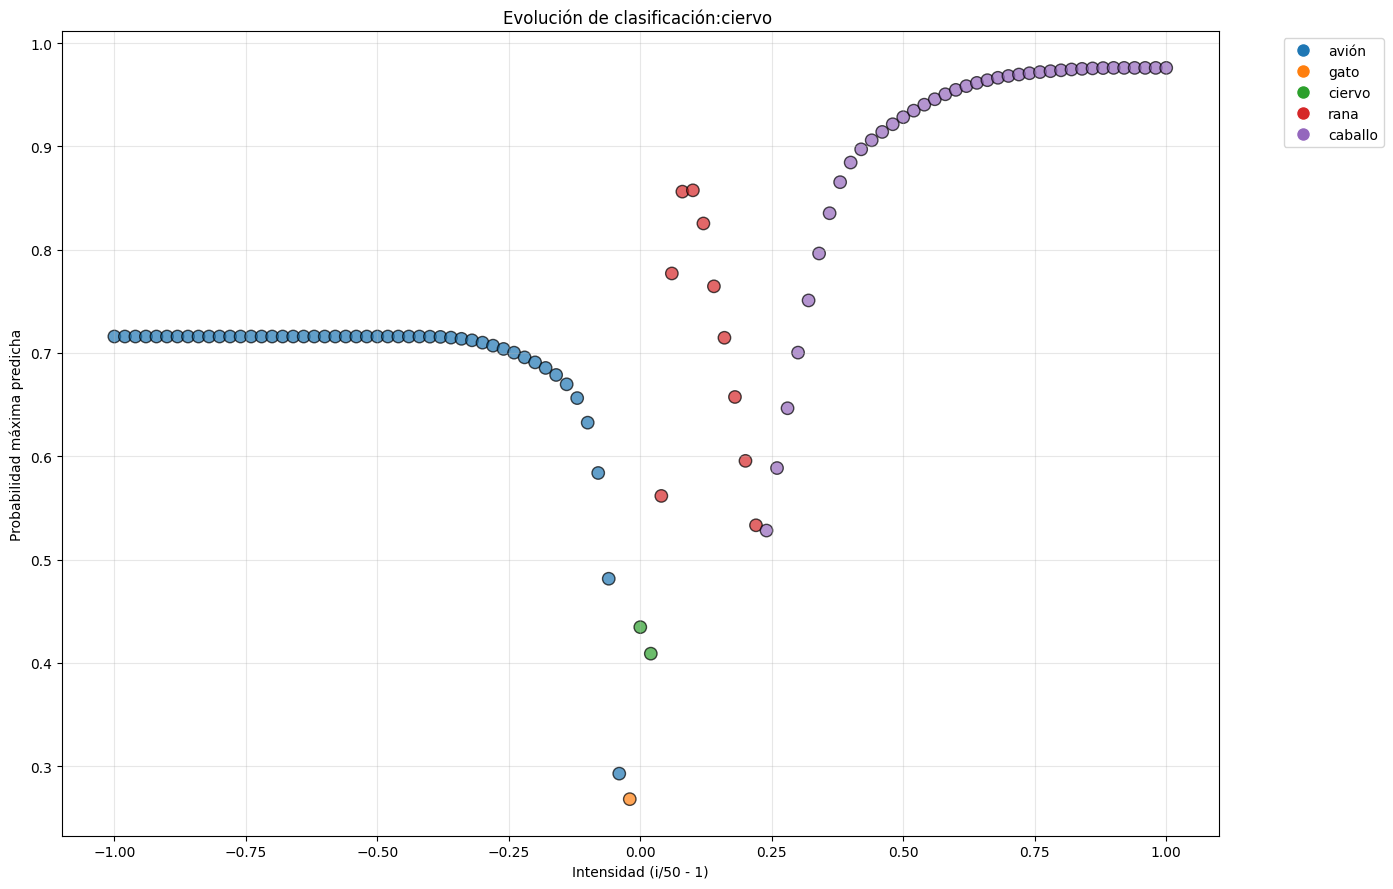

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━

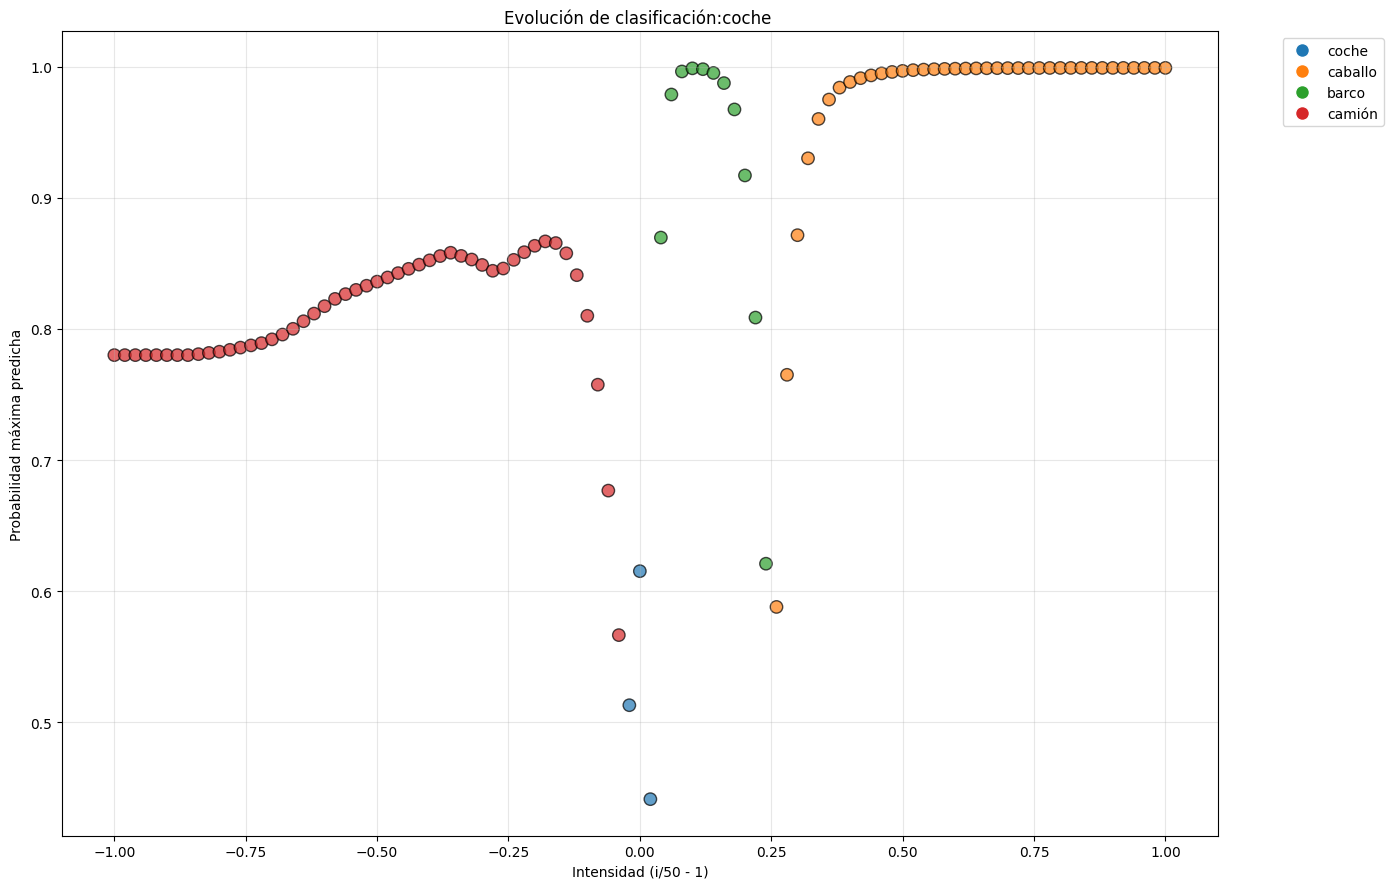

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━

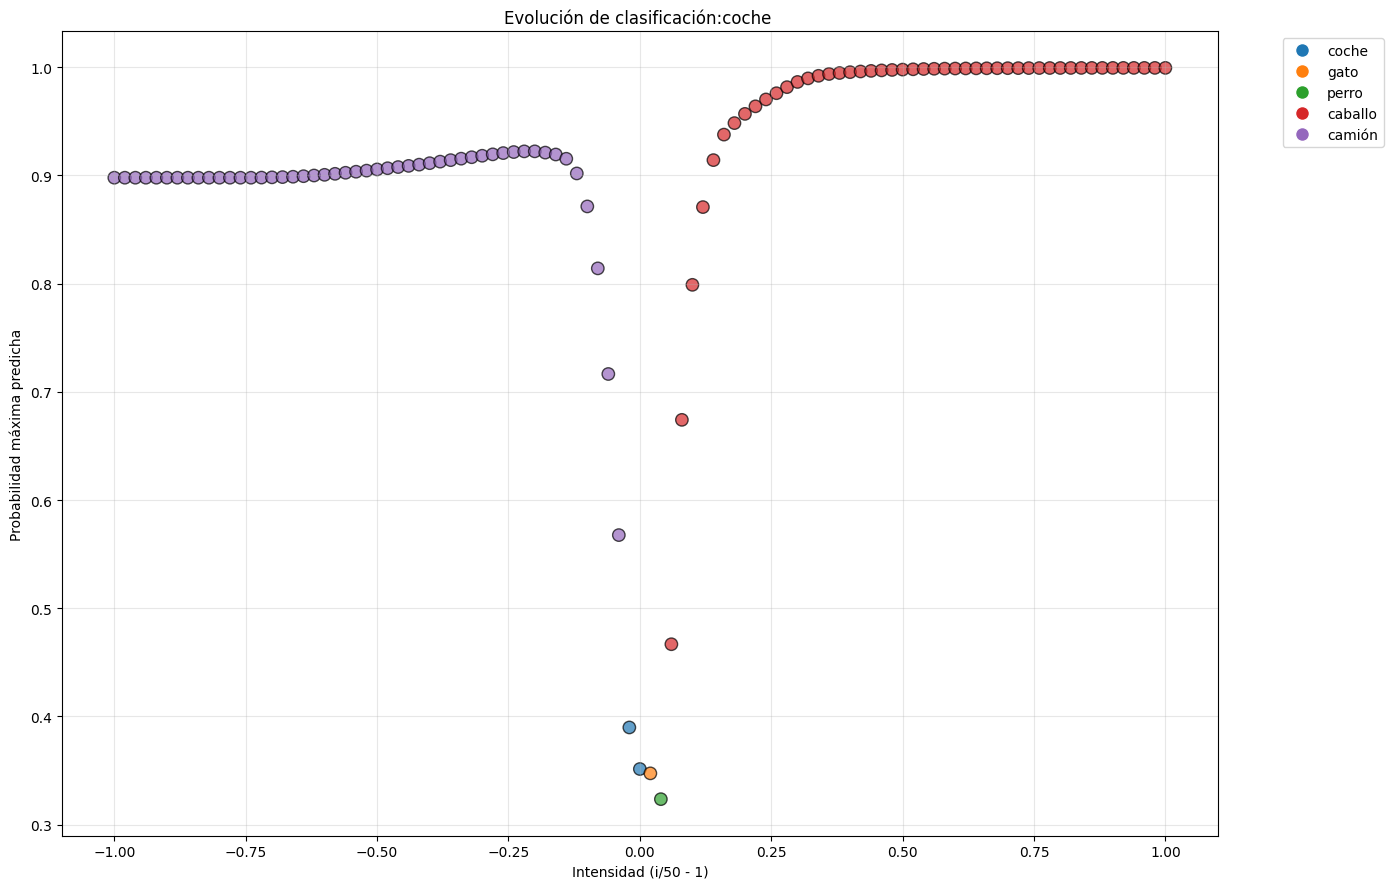

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━

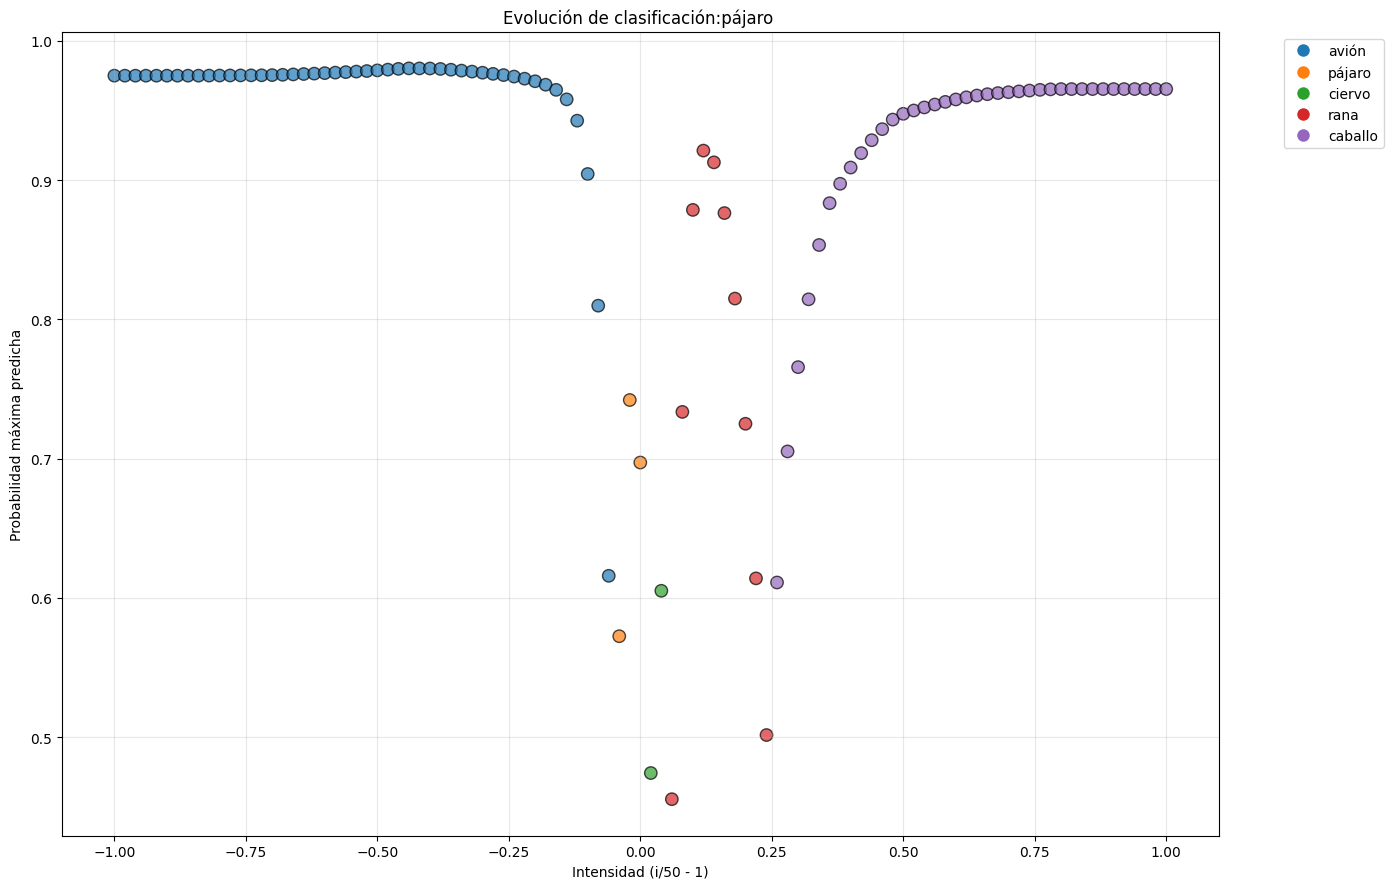

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━

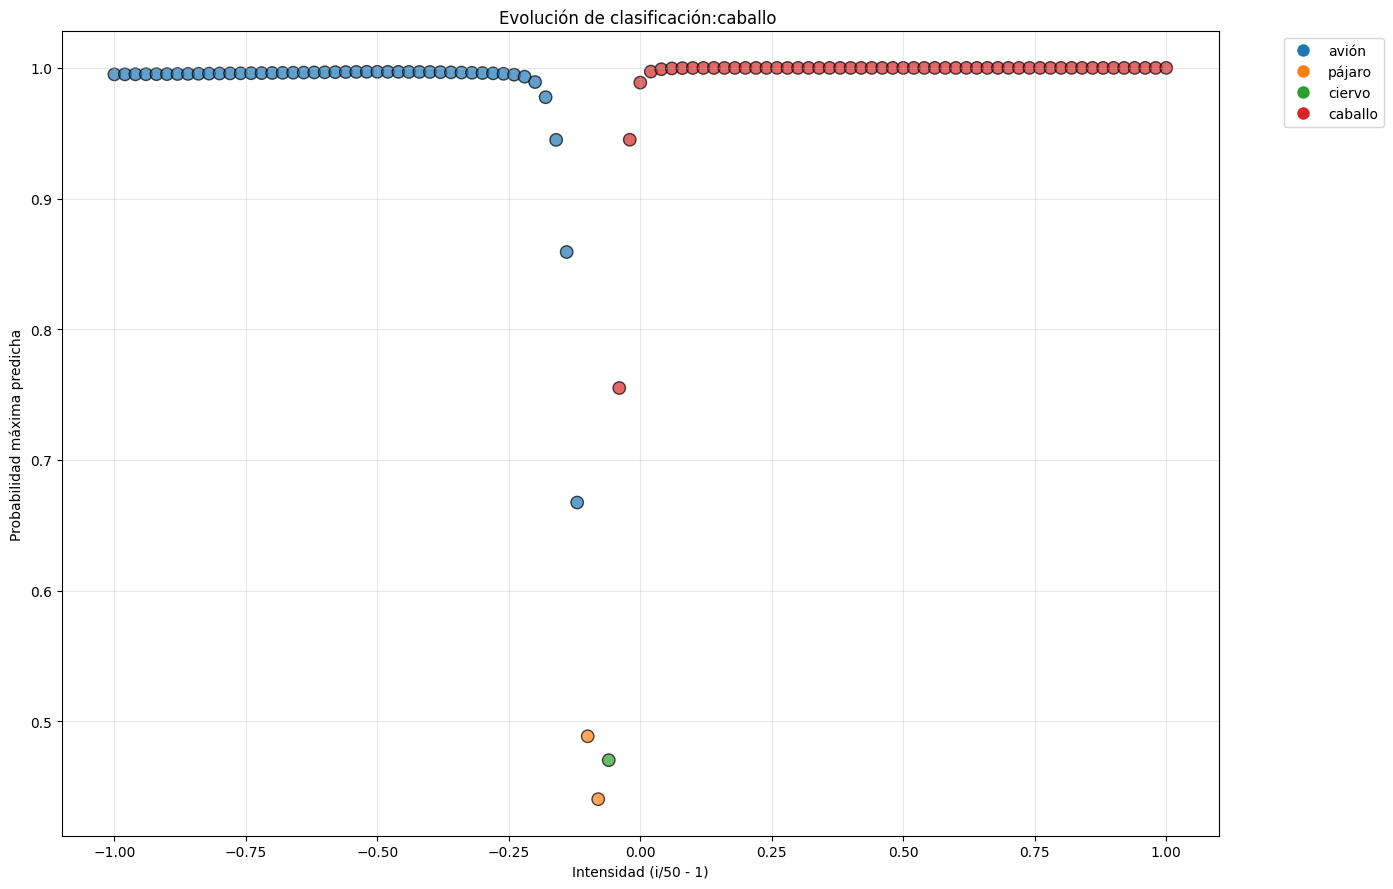

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━

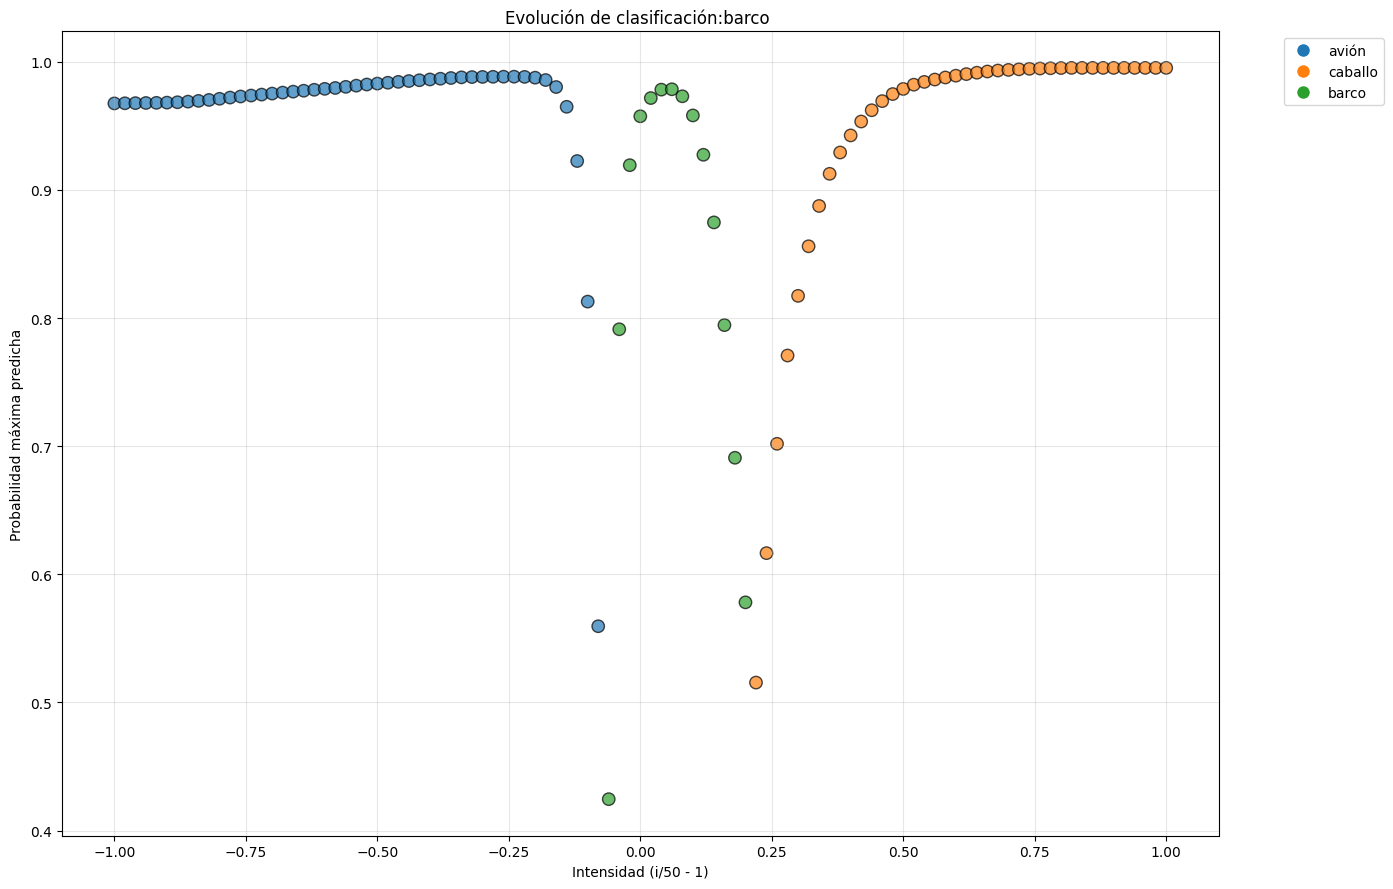

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━

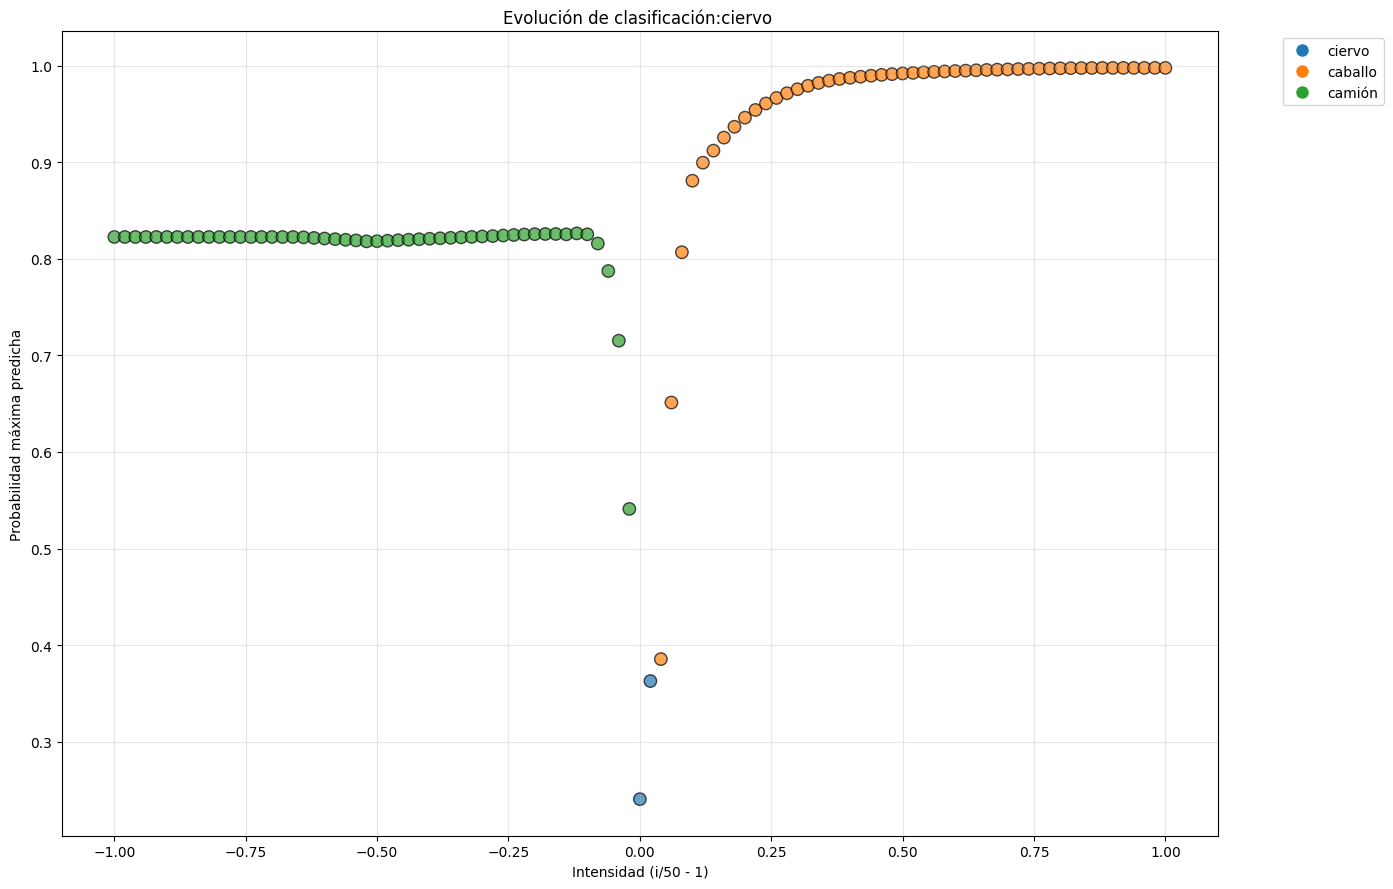

In [78]:
for idx in range(1,10):
    intensidades = []
    max_probs = []
    clases_pred = []

    x_img = X_train[idx:idx+1]  # (1, 32*32*3)

    for i in range(101):
        intensidad = (i/50 - 1)
        x_img_copia = x_img.copy()
        for k in range(len(filas)):
            x_img_copia.reshape(32, 32, 3)[filas[k]][columnas[k]] = np.clip(x_img_copia.reshape(32, 32, 3)[filas[k]][columnas[k]] + intensidad,0 ,1)
        y_pred = model.predict(x_img_copia)[0]
        intensidades.append(intensidad)
        max_probs.append(np.max(y_pred))
        clases_pred.append(np.argmax(y_pred))

    intensidades = np.array(intensidades)
    max_probs = np.array(max_probs)
    clases_pred = np.array(clases_pred)

    # Clases únicas realmente presentes
    unique_classes = np.unique(clases_pred)

    # Colores discretos: un color por clase presente
    cmap = plt.cm.tab10
    color_map = {cls_idx: cmap(i) for i, cls_idx in enumerate(unique_classes)}

    # Colores punto a punto, según su clase predicha
    point_colors = [color_map[cls] for cls in clases_pred]

    plt.figure(figsize=(14, 9))

    # Ahora usamos 'color=' en lugar de 'c=' y NO ponemos cmap
    plt.scatter(intensidades, max_probs,
                color=point_colors,
                s=80, alpha=0.7, edgecolors='black')

    plt.xlabel('Intensidad (i/50 - 1)')
    plt.ylabel('Probabilidad máxima predicha')
    plt.title(f"Evolución de clasificación:{clases[np.argmax(model.predict(x_img)[0])]} ")
    plt.grid(True, alpha=0.3)

    # Leyenda consistente con los mismos colores
    from matplotlib.lines import Line2D
    legend_elements = []
    for cls_idx in unique_classes:
        legend_elements.append(
            Line2D([0], [0],
                marker='o', color='w',
                markerfacecolor=color_map[cls_idx],
                markersize=10,
                label=clases[cls_idx])
        )

    plt.legend(handles=legend_elements, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

Observamos que para una única imagen, somos capaces de cambiar su clasificación en 5 posibilidades unicamente modificando la intensidad de los pixeles críticos.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


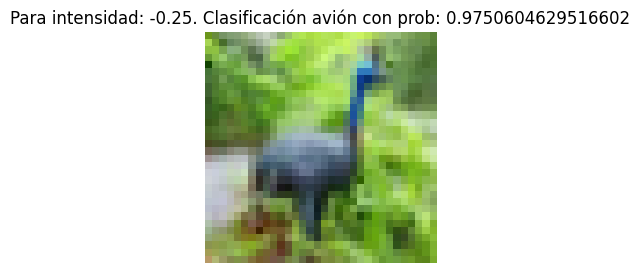

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


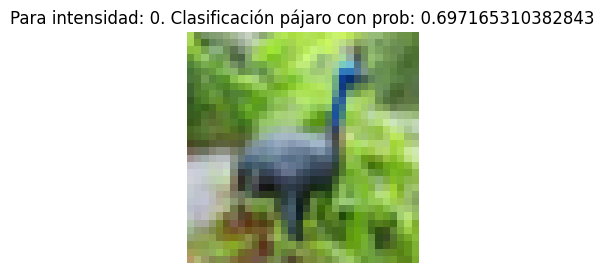

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


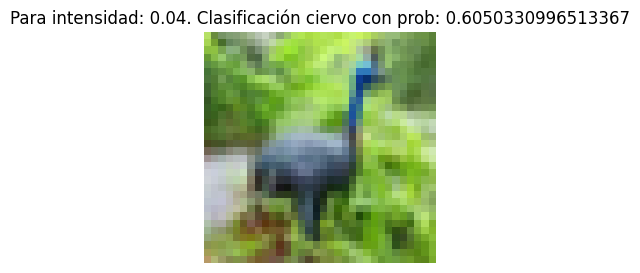

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


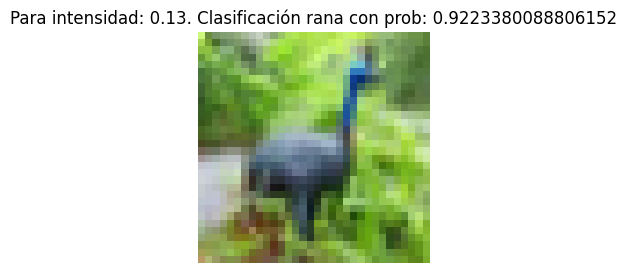

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


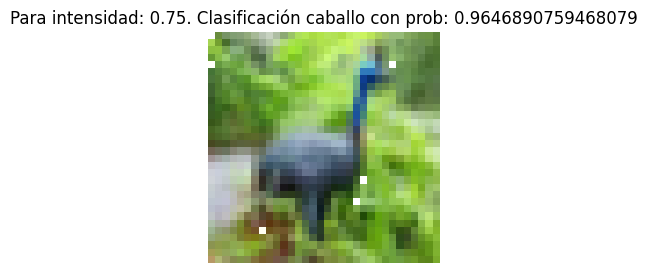

In [79]:
idx = 6
intensidades = [-0.25,0,0.04,0.13,0.75]


x_img = X_train[idx:idx+1]  # (1, 32*32*3)

for intensidad in intensidades:
    x_img_copia = x_img.copy()
    for k in range(len(filas)):
        x_img_copia.reshape(32, 32, 3)[filas[k]][columnas[k]] = np.clip(x_img_copia.reshape(32, 32, 3)[filas[k]][columnas[k]] + intensidad,0 ,1)

    y_pred = model.predict(x_img_copia)[0]
    max_probs = np.max(y_pred)
    clases_pred = np.argmax(y_pred)
    plt.figure(figsize=(8,3))
    plt.title(f"Para intensidad: {intensidad}. Clasificación {clases[clases_pred]} con prob: {max_probs}")
    plt.imshow(x_img_copia.reshape(32,32,3))
    plt.axis("off")
    plt.show()



Además parece que siempre clasifica como caballo cuando la intensidad es muy alta, y como camión/avión cuando la intensidad es muy baja.

Vamos a estudiarlo con más detalle con una imagen en neutro que cambie la intensidad de los pixeles críticos.

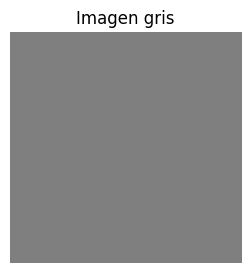

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━

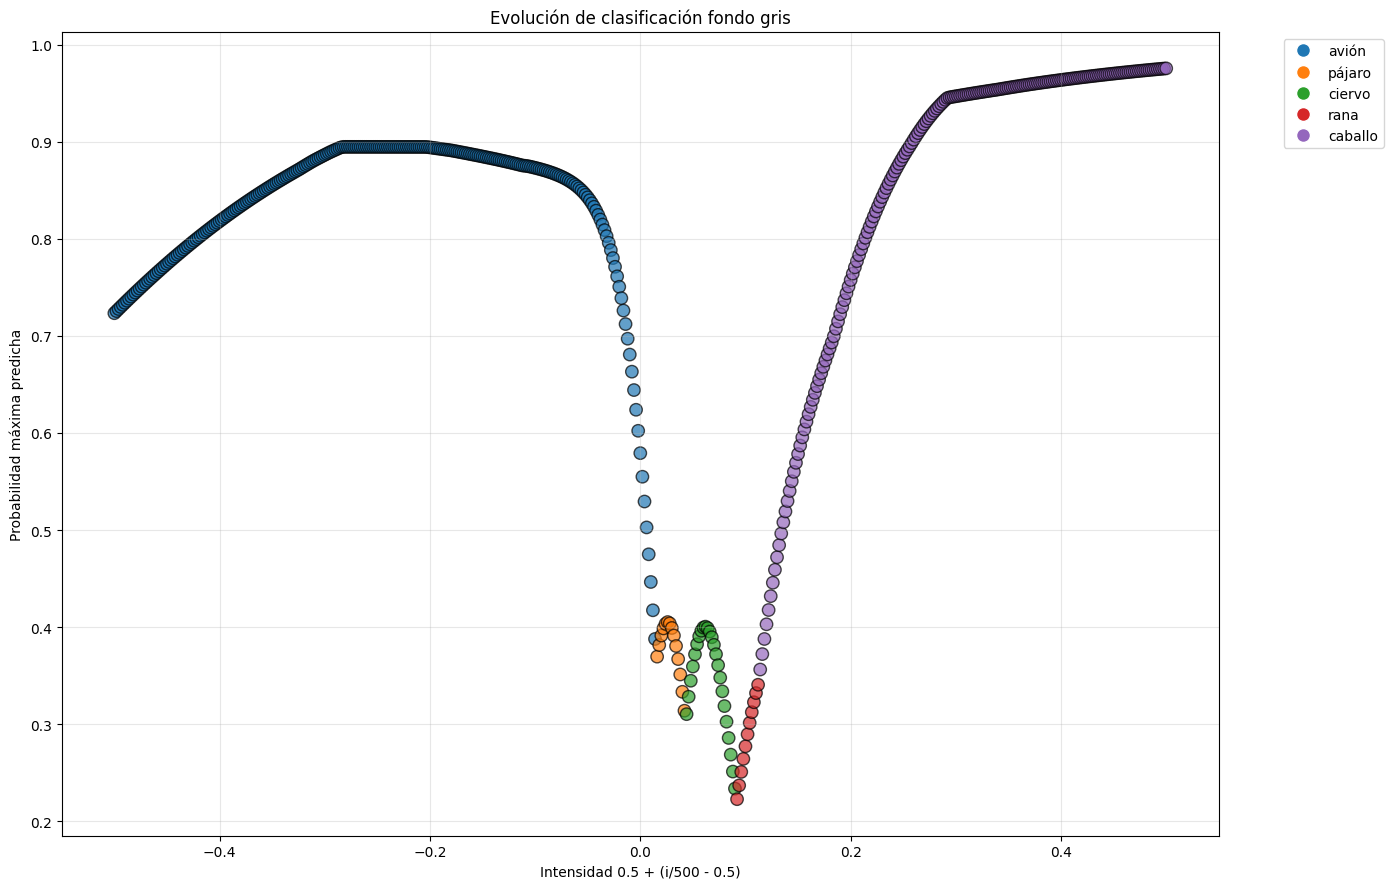

In [80]:
intensidades = []
max_probs = []
clases_pred = []

# Imagen a tonalidad de grises
x_img = np.full((1, 32*32*3), 0.5, dtype=np.float32)

plt.figure(figsize=(8,3))
plt.title("Imagen gris")
plt.imshow(x_img.reshape(32,32,3))
plt.axis("off")
plt.show()

for i in range(501):
    intensidad = (i/500 - 0.5)
    x_img_copia = x_img.copy()
    for k in range(len(filas)):
        x_img_copia.reshape(32, 32, 3)[filas[k]][columnas[k]] = np.clip(x_img_copia.reshape(32, 32, 3)[filas[k]][columnas[k]] + intensidad,0 ,1)
    y_pred = model.predict(x_img_copia)[0]
    intensidades.append(intensidad)
    max_probs.append(np.max(y_pred))
    clases_pred.append(np.argmax(y_pred))

intensidades = np.array(intensidades)
max_probs = np.array(max_probs)
clases_pred = np.array(clases_pred)

# Clases únicas realmente presentes
unique_classes = np.unique(clases_pred)

# Colores discretos: un color por clase presente
cmap = plt.cm.tab10
color_map = {cls_idx: cmap(i) for i, cls_idx in enumerate(unique_classes)}

# Colores punto a punto, según su clase predicha
point_colors = [color_map[cls] for cls in clases_pred]

plt.figure(figsize=(14, 9))

plt.scatter(intensidades, max_probs,
            color=point_colors,
            s=80, alpha=0.7, edgecolors='black')

plt.xlabel('Intensidad 0.5 + (i/500 - 0.5)')
plt.ylabel('Probabilidad máxima predicha')
plt.title('Evolución de clasificación fondo gris')
plt.grid(True, alpha=0.3)

# Leyenda consistente con los mismos colores
from matplotlib.lines import Line2D
legend_elements = []
for cls_idx in unique_classes:
    legend_elements.append(
        Line2D([0], [0],
               marker='o', color='w',
               markerfacecolor=color_map[cls_idx],
               markersize=10,
               label=clases[cls_idx])
    )

plt.legend(handles=legend_elements, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Mediante una imagen en gris, somos capaces de cambiar solo 6 pixeles para obtener 6 clasificaciones distintas.

Resultados obtenidos:
* Avion: Intensidad oscura 
* Pajaro: Intensdiad neutra
* Ciervo: Intensidad +0.05
* Perro: Intensidad +0.1
* Rana: Intensidad +0.15
* Caballo: Intensidad clara

Faltaría saber que pasa con el resto de clases:
* Coche
* Gato
* Barco
* Camión

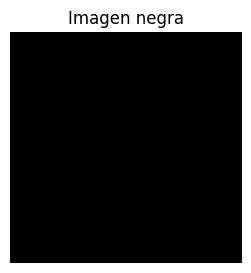

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━

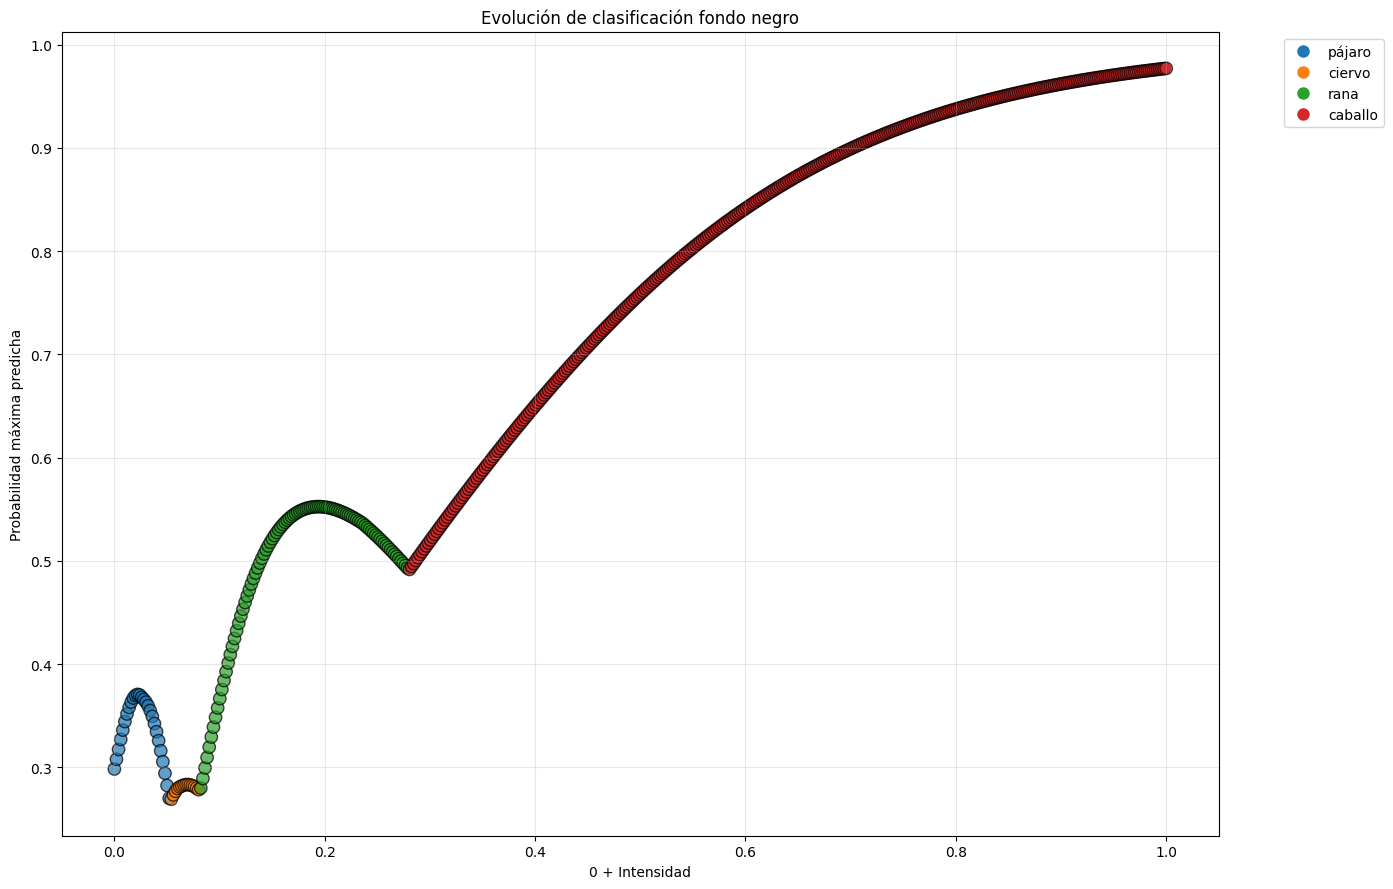

In [81]:
intensidades = []
max_probs = []
clases_pred = []

# Imagen a tonalidad de negro
x_img = np.full((1, 32*32*3), 0, dtype=np.float32)

plt.figure(figsize=(8,3))
plt.title("Imagen negra")
plt.imshow(x_img.reshape(32,32,3))
plt.axis("off")
plt.show()

for intensidad in np.linspace(0,1,500):
    x_img_copia = x_img.copy()
    for k in range(len(filas)):
        x_img_copia.reshape(32, 32, 3)[filas[k]][columnas[k]] = np.clip(x_img_copia.reshape(32, 32, 3)[filas[k]][columnas[k]] + intensidad,0 ,1)
    y_pred = model.predict(x_img_copia)[0]
    intensidades.append(intensidad)
    max_probs.append(np.max(y_pred))
    clases_pred.append(np.argmax(y_pred))

intensidades = np.array(intensidades)
max_probs = np.array(max_probs)
clases_pred = np.array(clases_pred)

# Clases únicas realmente presentes
unique_classes = np.unique(clases_pred)

# Colores discretos: un color por clase presente
cmap = plt.cm.tab10
color_map = {cls_idx: cmap(i) for i, cls_idx in enumerate(unique_classes)}

# Colores punto a punto, según su clase predicha
point_colors = [color_map[cls] for cls in clases_pred]

plt.figure(figsize=(14, 9))

plt.scatter(intensidades, max_probs,
            color=point_colors,
            s=80, alpha=0.7, edgecolors='black')

plt.xlabel('0 + Intensidad')
plt.ylabel('Probabilidad máxima predicha')
plt.title('Evolución de clasificación fondo negro')
plt.grid(True, alpha=0.3)

# Leyenda consistente con los mismos colores
from matplotlib.lines import Line2D
legend_elements = []
for cls_idx in unique_classes:
    legend_elements.append(
        Line2D([0], [0],
               marker='o', color='w',
               markerfacecolor=color_map[cls_idx],
               markersize=10,
               label=clases[cls_idx])
    )

plt.legend(handles=legend_elements, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

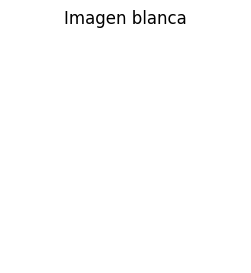

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━

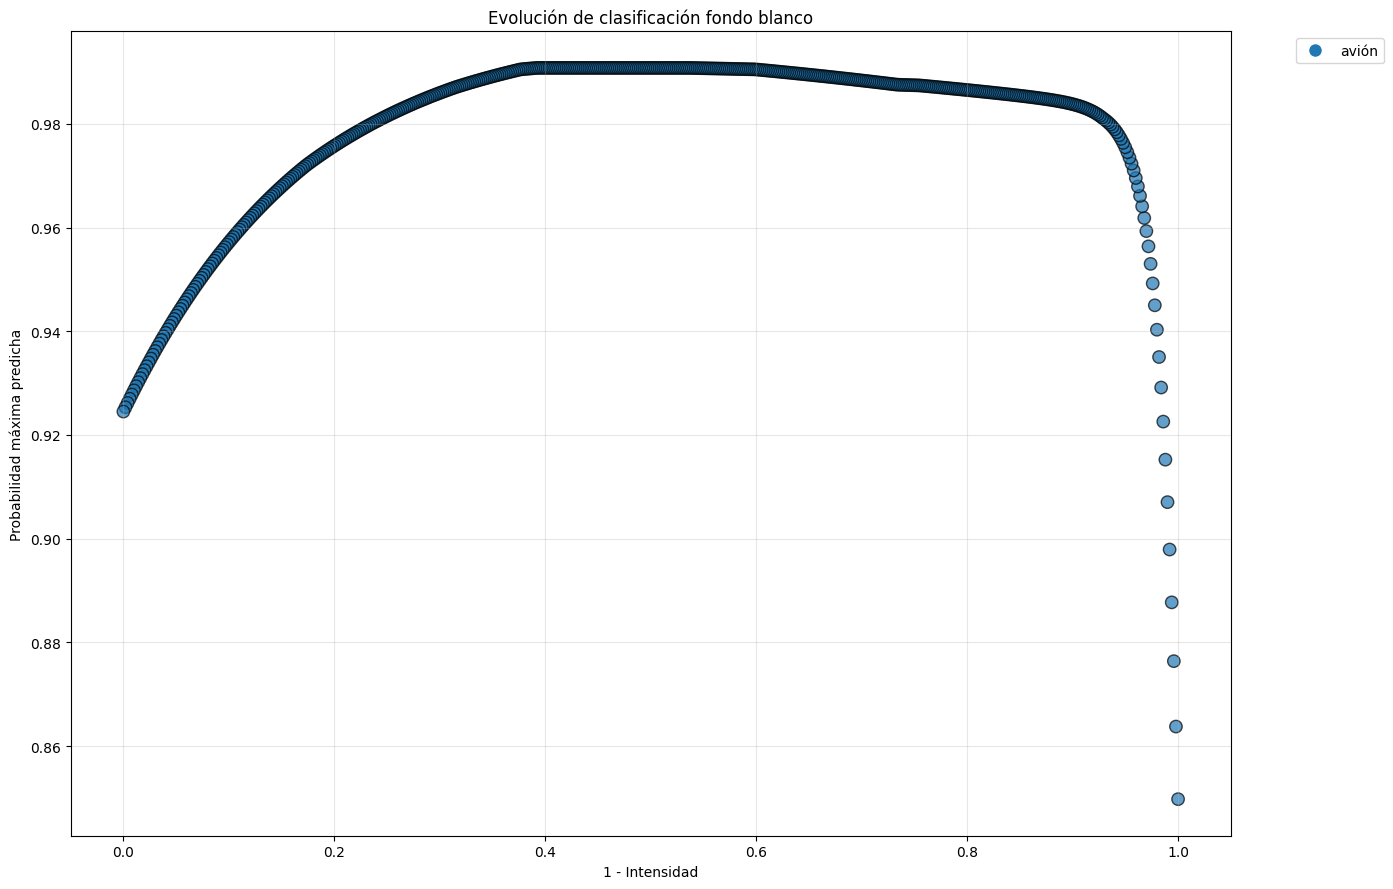

In [82]:
intensidades = []
max_probs = []
clases_pred = []

# Imagen a tonalidad de blanca
x_img = np.full((1, 32*32*3), 1, dtype=np.float32)

plt.figure(figsize=(8,3))
plt.title("Imagen blanca")
plt.imshow(x_img.reshape(32,32,3))
plt.axis("off")
plt.show()

for intensidad in np.linspace(0,1,500):
    x_img_copia = x_img.copy()
    for k in range(len(filas)):
        x_img_copia.reshape(32, 32, 3)[filas[k]][columnas[k]] = np.clip(x_img_copia.reshape(32, 32, 3)[filas[k]][columnas[k]] - intensidad,0 ,1)
    y_pred = model.predict(x_img_copia)[0]
    intensidades.append(1-intensidad)
    max_probs.append(np.max(y_pred))
    clases_pred.append(np.argmax(y_pred))

intensidades = np.array(intensidades)
max_probs = np.array(max_probs)
clases_pred = np.array(clases_pred)

# Clases únicas realmente presentes
unique_classes = np.unique(clases_pred)

# Colores discretos: un color por clase presente
cmap = plt.cm.tab10
color_map = {cls_idx: cmap(i) for i, cls_idx in enumerate(unique_classes)}

# Colores punto a punto, según su clase predicha
point_colors = [color_map[cls] for cls in clases_pred]

plt.figure(figsize=(14, 9))

plt.scatter(intensidades, max_probs,
            color=point_colors,
            s=80, alpha=0.7, edgecolors='black')

plt.xlabel('1 - Intensidad')
plt.ylabel('Probabilidad máxima predicha')
plt.title('Evolución de clasificación fondo blanco')
plt.grid(True, alpha=0.3)

# Leyenda consistente con los mismos colores
from matplotlib.lines import Line2D
legend_elements = []
for cls_idx in unique_classes:
    legend_elements.append(
        Line2D([0], [0],
               marker='o', color='w',
               markerfacecolor=color_map[cls_idx],
               markersize=10,
               label=clases[cls_idx])
    )

plt.legend(handles=legend_elements, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Vamos a tratar de encontrar alguna relación con la clase camión. Partiendo de la imagen de los 10 ejemplos anteriores.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━

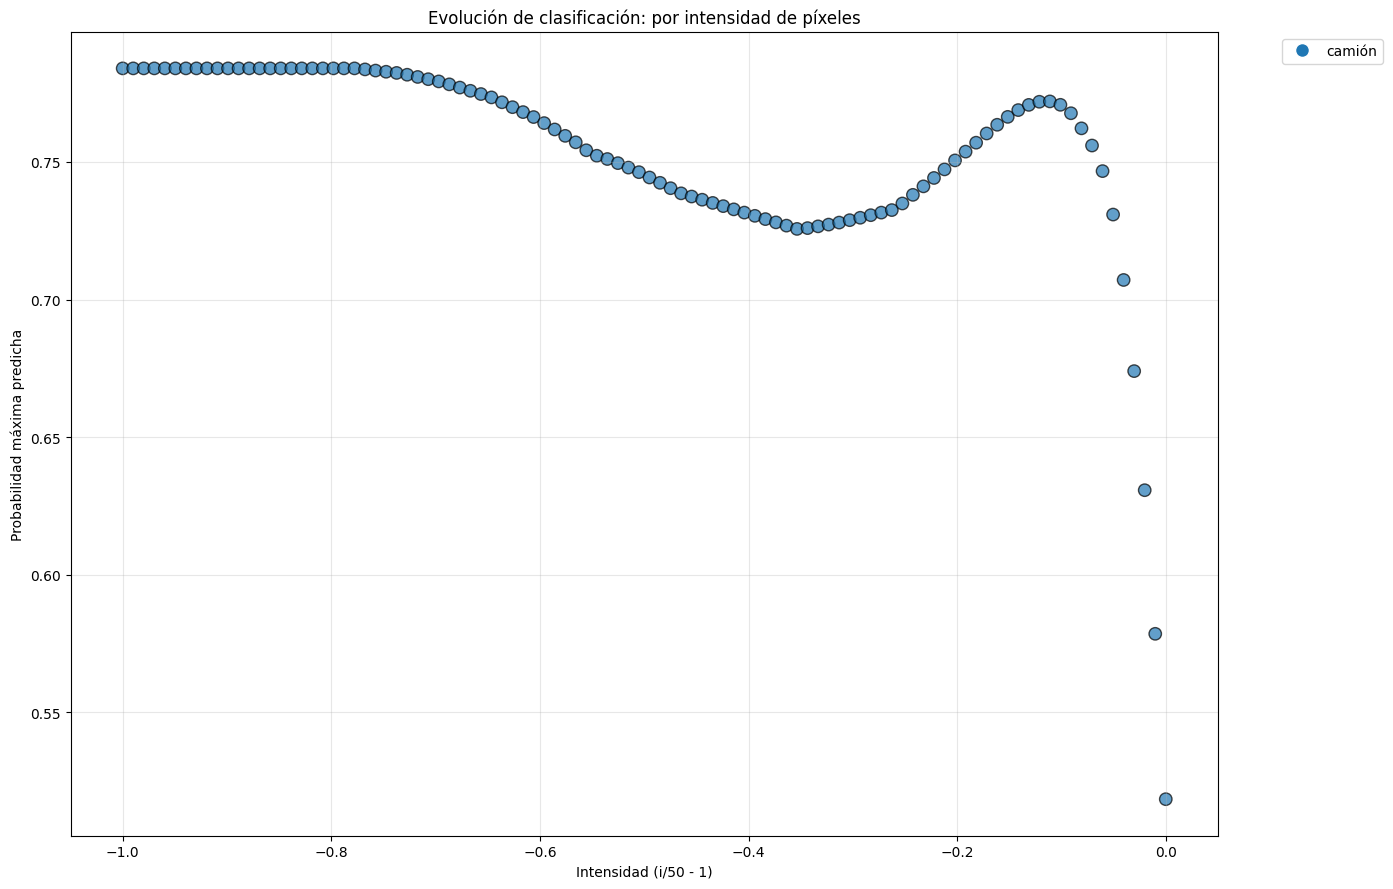

In [83]:
intensidades = []
max_probs = []
clases_pred = []

# Camion (-1,0) idx 1
# Coche (0,0.1) idx 1
# Gato (0.1,0.15) idx 2
# Barco (0.05,0.2) idx 4
idx = 1
x_img = X_train[idx:idx+1]

for intensidad in np.linspace(-1,0,100):
    x_img_copia = x_img.copy()
    for k in range(len(filas)):
        x_img_copia.reshape(32, 32, 3)[filas[k]][columnas[k]] = np.clip(x_img_copia.reshape(32, 32, 3)[filas[k]][columnas[k]] + intensidad,0 ,1)
    y_pred = model.predict(x_img_copia)[0]
    intensidades.append(intensidad)
    max_probs.append(np.max(y_pred))
    clases_pred.append(np.argmax(y_pred))

intensidades = np.array(intensidades)
max_probs = np.array(max_probs)
clases_pred = np.array(clases_pred)

# Clases únicas realmente presentes
unique_classes = np.unique(clases_pred)

# Colores discretos: un color por clase presente
cmap = plt.cm.tab10
color_map = {cls_idx: cmap(i) for i, cls_idx in enumerate(unique_classes)}

# Colores punto a punto, según su clase predicha
point_colors = [color_map[cls] for cls in clases_pred]

plt.figure(figsize=(14, 9))

plt.scatter(intensidades, max_probs,
            color=point_colors,
            s=80, alpha=0.7, edgecolors='black')

plt.xlabel('Intensidad (i/50 - 1)')
plt.ylabel('Probabilidad máxima predicha')
plt.title('Evolución de clasificación: por intensidad de píxeles')
plt.grid(True, alpha=0.3)

# Leyenda consistente con los mismos colores
from matplotlib.lines import Line2D
legend_elements = []
for cls_idx in unique_classes:
    legend_elements.append(
        Line2D([0], [0],
               marker='o', color='w',
               markerfacecolor=color_map[cls_idx],
               markersize=10,
               label=clases[cls_idx])
    )

plt.legend(handles=legend_elements, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

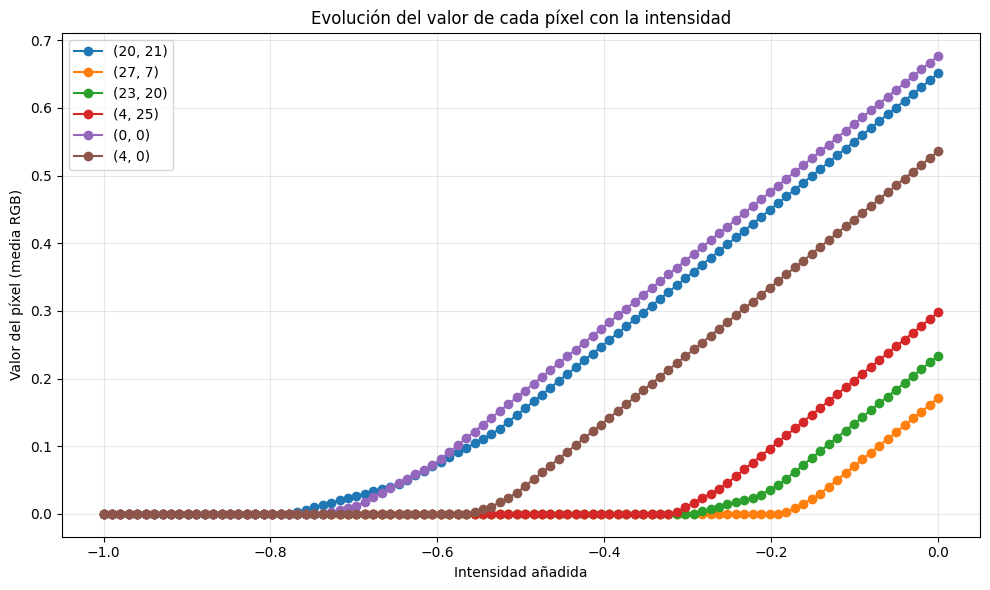

In [84]:
intensidades = np.linspace(-1, 0, 100)
n_pix = len(filas)

# valores_pixeles[k, t] = valor del píxel k en la intensidad t
valores_pixeles = np.zeros((n_pix, len(intensidades)), dtype=np.float32)

idx = 1
x_img = X_train[idx:idx+1]  # (1, 32*32*3)

for t, intensidad in enumerate(intensidades):
    x_img_copia = x_img.copy()
    x_reshaped = x_img_copia.reshape(32, 32, 3)

    for k in range(n_pix):
        f, c = filas[k], columnas[k]
        x_reshaped[f, c] = np.clip(x_reshaped[f, c] + intensidad, 0, 1)
        # Guardamos el valor del píxel (puede ser vector RGB; si quieres un canal, ajusta aquí)
        # Si quieres, por ejemplo, la media del RGB:
        valores_pixeles[k, t] = x_reshaped[f, c].mean()

    # Si quieres seguir usando el modelo, aquí volverías a (1, 32*32*3)
    x_img_copia = x_reshaped.reshape(1, -1)
    y_pred = model.predict(x_img_copia, verbose=0)[0]
    # (si quieres, aquí sigues rellenando max_probs, clases_pred, etc.)


plt.figure(figsize=(10, 6))

for k in range(n_pix):
    etiqueta = f"({filas[k]}, {columnas[k]})"
    plt.plot(intensidades, valores_pixeles[k], marker='o', label=etiqueta)

plt.xlabel('Intensidad añadida')
plt.ylabel('Valor del píxel (media RGB)')
plt.title('Evolución del valor de cada píxel con la intensidad')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━

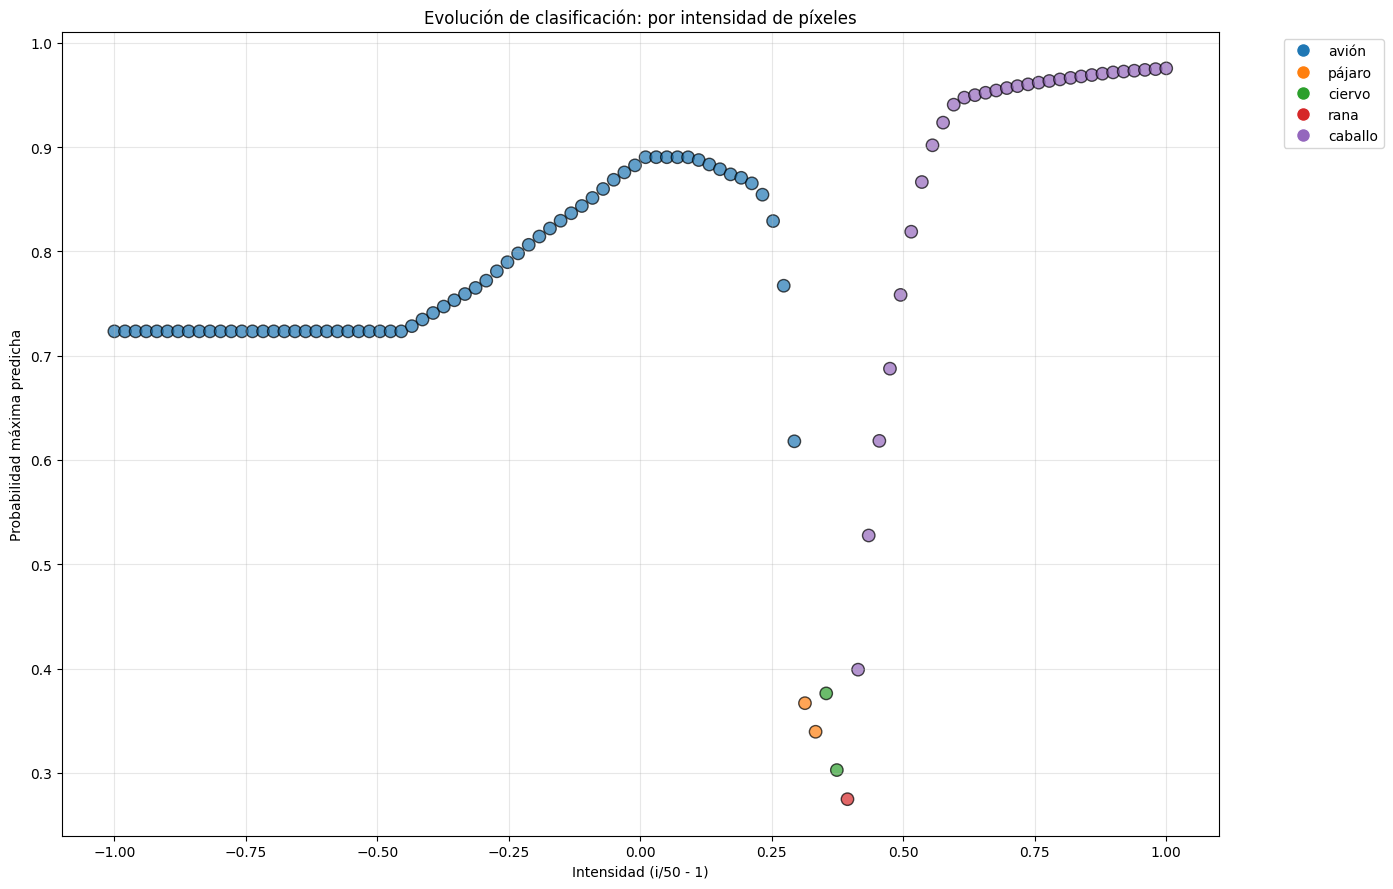

In [85]:
intensidades = []
max_probs  = []
clases_pred  = []

# Imagen a tonalidad de grises
x_img = np.full((1, 32*32*3), 0.5, dtype=np.float32)

#cambiamos la tonalidad de los pixeles criticos para romper uniformidad
for k in [(20,21,0.45), (0,0,0.45), (4,0,0.3), (4,25,0.1), (23,20,0), (27,7,0)]:
    x_img.reshape(32, 32, 3)[k[0]][k[1]] = np.ones((1,1,1)) * k[2]



for intensidad in np.linspace(-1,1,100):
    x_img_copia = x_img.copy()
    for k in range(len(filas)):
        x_img_copia.reshape(32, 32, 3)[filas[k]][columnas[k]] = np.clip(x_img_copia.reshape(32, 32, 3)[filas[k]][columnas[k]] + intensidad,0 ,1)
    y_pred = model.predict(x_img_copia)[0]
    intensidades.append(intensidad)
    max_probs.append(np.max(y_pred))
    clases_pred.append(np.argmax(y_pred))

intensidades = np.array(intensidades)
max_probs = np.array(max_probs)
clases_pred = np.array(clases_pred)

# Clases únicas realmente presentes
unique_classes = np.unique(clases_pred)

# Colores discretos: un color por clase presente
cmap = plt.cm.tab10
color_map = {cls_idx: cmap(i) for i, cls_idx in enumerate(unique_classes)}

# Colores punto a punto, según su clase predicha
point_colors = [color_map[cls] for cls in clases_pred]

plt.figure(figsize=(14, 9))

plt.scatter(intensidades, max_probs,
            color=point_colors,
            s=80, alpha=0.7, edgecolors='black')

plt.xlabel('Intensidad (i/50 - 1)')
plt.ylabel('Probabilidad máxima predicha')
plt.title('Evolución de clasificación: por intensidad de píxeles')
plt.grid(True, alpha=0.3)

# Leyenda consistente con los mismos colores
from matplotlib.lines import Line2D
legend_elements = []
for cls_idx in unique_classes:
    legend_elements.append(
        Line2D([0], [0],
               marker='o', color='w',
               markerfacecolor=color_map[cls_idx],
               markersize=10,
               label=clases[cls_idx])
    )

plt.legend(handles=legend_elements, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()



Parece que aun rompiendo uniformidad, no consigo clasificar la clase camión. Requiere de un mejor estudio para encontrar la razón subyacente, analizando con más tiempo los datos que tengo para encontrar la relación.

---